# Интерпретация

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

import lime
import lime.lime_tabular
import shap

%config InlineBackend.figure_format = 'retina'


### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [30]:

data_path = r'/home/alexandra/Документы/ml_practice/datasets/hw_interpretation/data.csv'
data = pd.read_csv(data_path, sep=',')
print(data.shape)
print(data.dtypes.value_counts())
data.head()

(29905, 83)
float64    74
int64       6
str         3
Name: count, dtype: int64


,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.000000,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.000000,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.000000,0.945618,7.0,18311.834458,284,49786.0,97865,70661
3,Город,14,1053,121,2012-12-10,10.0,57.48,2,23.286900,13.0,...,0.913797,1.028386,0.300026,0.828147,5.0,25171.489968,325,0.0,97865,12638
4,Город,63,2426,69,2012-02-12,3.0,41.43,1,20.599150,13.0,...,1.051049,-999.000000,-999.000000,0.991506,4.0,27324.795343,182,49786.0,97865,70661


In [37]:
Q1 = data['price_target'].quantile(0.25)
Q3 = data['price_target'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['price_target'] < lower) | 
                (data['price_target'] > upper)]
print(f"Выбросов: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")
print(f"Диапазон нормальных значений: [{lower:.0f}, {upper:.0f}]")

Выбросов: 1259 (4.2%)
Диапазон нормальных значений: [3588, 42071]


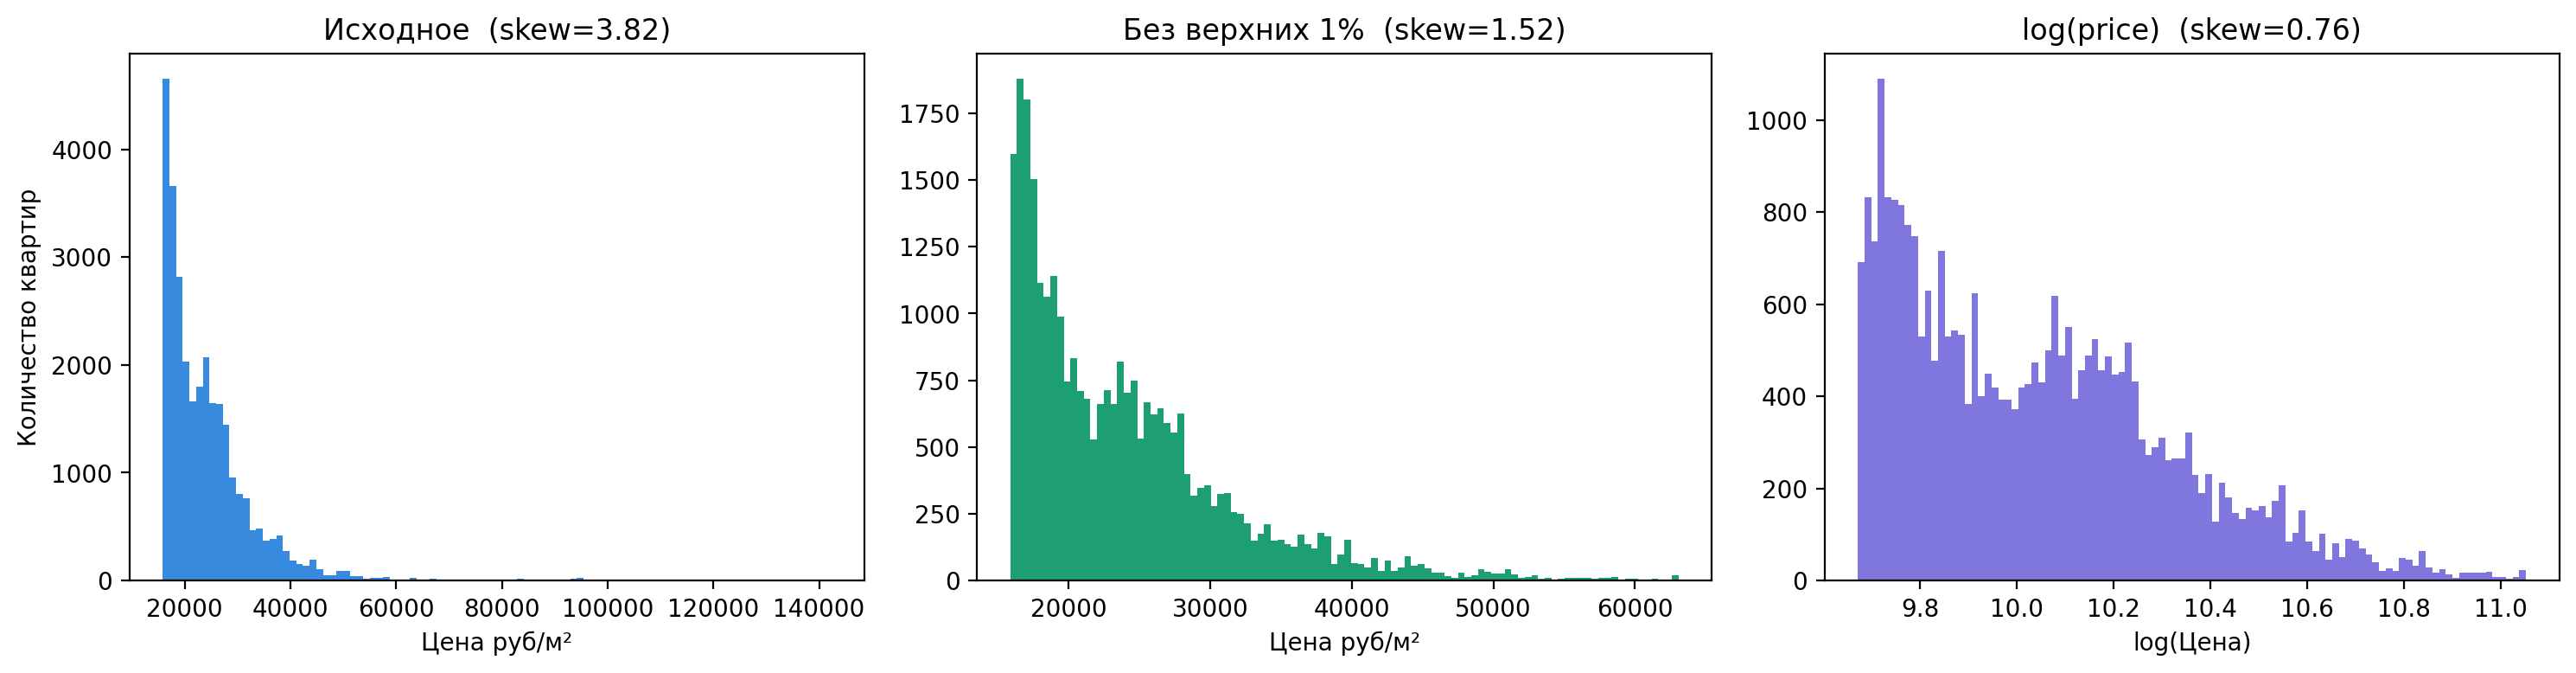

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(data['price_target'], bins=100, color='#378ADD', edgecolor='none')
axes[0].set_title(f'Исходное  (skew={data["price_target"].skew():.2f})')
axes[0].set_xlabel('Цена руб/м²')
axes[0].set_ylabel('Количество квартир')

p99 = data['price_target'].quantile(0.99)
data_trimmed = data[data['price_target'] <= p99]

axes[1].hist(data_trimmed['price_target'], bins=100, 
             color='#1D9E75', edgecolor='none')
axes[1].set_title(f'Без верхних 1%  (skew={data_trimmed["price_target"].skew():.2f})')
axes[1].set_xlabel('Цена руб/м²')

log_prices = np.log1p(data_trimmed['price_target'])

axes[2].hist(log_prices, bins=100, color='#7F77DD', edgecolor='none')
axes[2].set_title(f'log(price)  (skew={log_prices.skew():.2f})')
axes[2].set_xlabel('log(Цена)')

plt.tight_layout() 
plt.show()

In [32]:

cols_with_sentinel = []
for col in data.select_dtypes(include=[np.number]).columns:
    if (data[col] == -999).any():
        count = (data[col] == -999).sum()
        pct = count / len(data) * 100
        cols_with_sentinel.append((col, count, pct))

sentinel_df = pd.DataFrame(cols_with_sentinel, 
                            columns=['feature', 'count', 'pct'])
print(sentinel_df.sort_values('pct', ascending=False))

                                              feature  count        pct
8                       location_town_w_mean_distance  21210  70.924595
28                location_university_w_mean_distance  20429  68.312991
6                 location_commercial_w_mean_distance  19517  65.263334
17           location_amenity_leisure_w_mean_distance  10497  35.101154
27                     location_water_w_mean_distance   9116  30.483197
0                      location_hotel_w_mean_distance   8234  27.533857
7                 location_industrial_w_mean_distance   5437  18.180906
12           location_railway_station_w_mean_distance   4866  16.271527
13                    location_social_w_mean_distance   4837  16.174553
22                 location_shop_alco_w_mean_distance   3672  12.278883
18                   location_tourism_w_mean_distance   3601  12.041465
1                   location_pop_bank_w_mean_distance   3058  10.225715
4                       location_fuel_w_mean_distance   2799   9

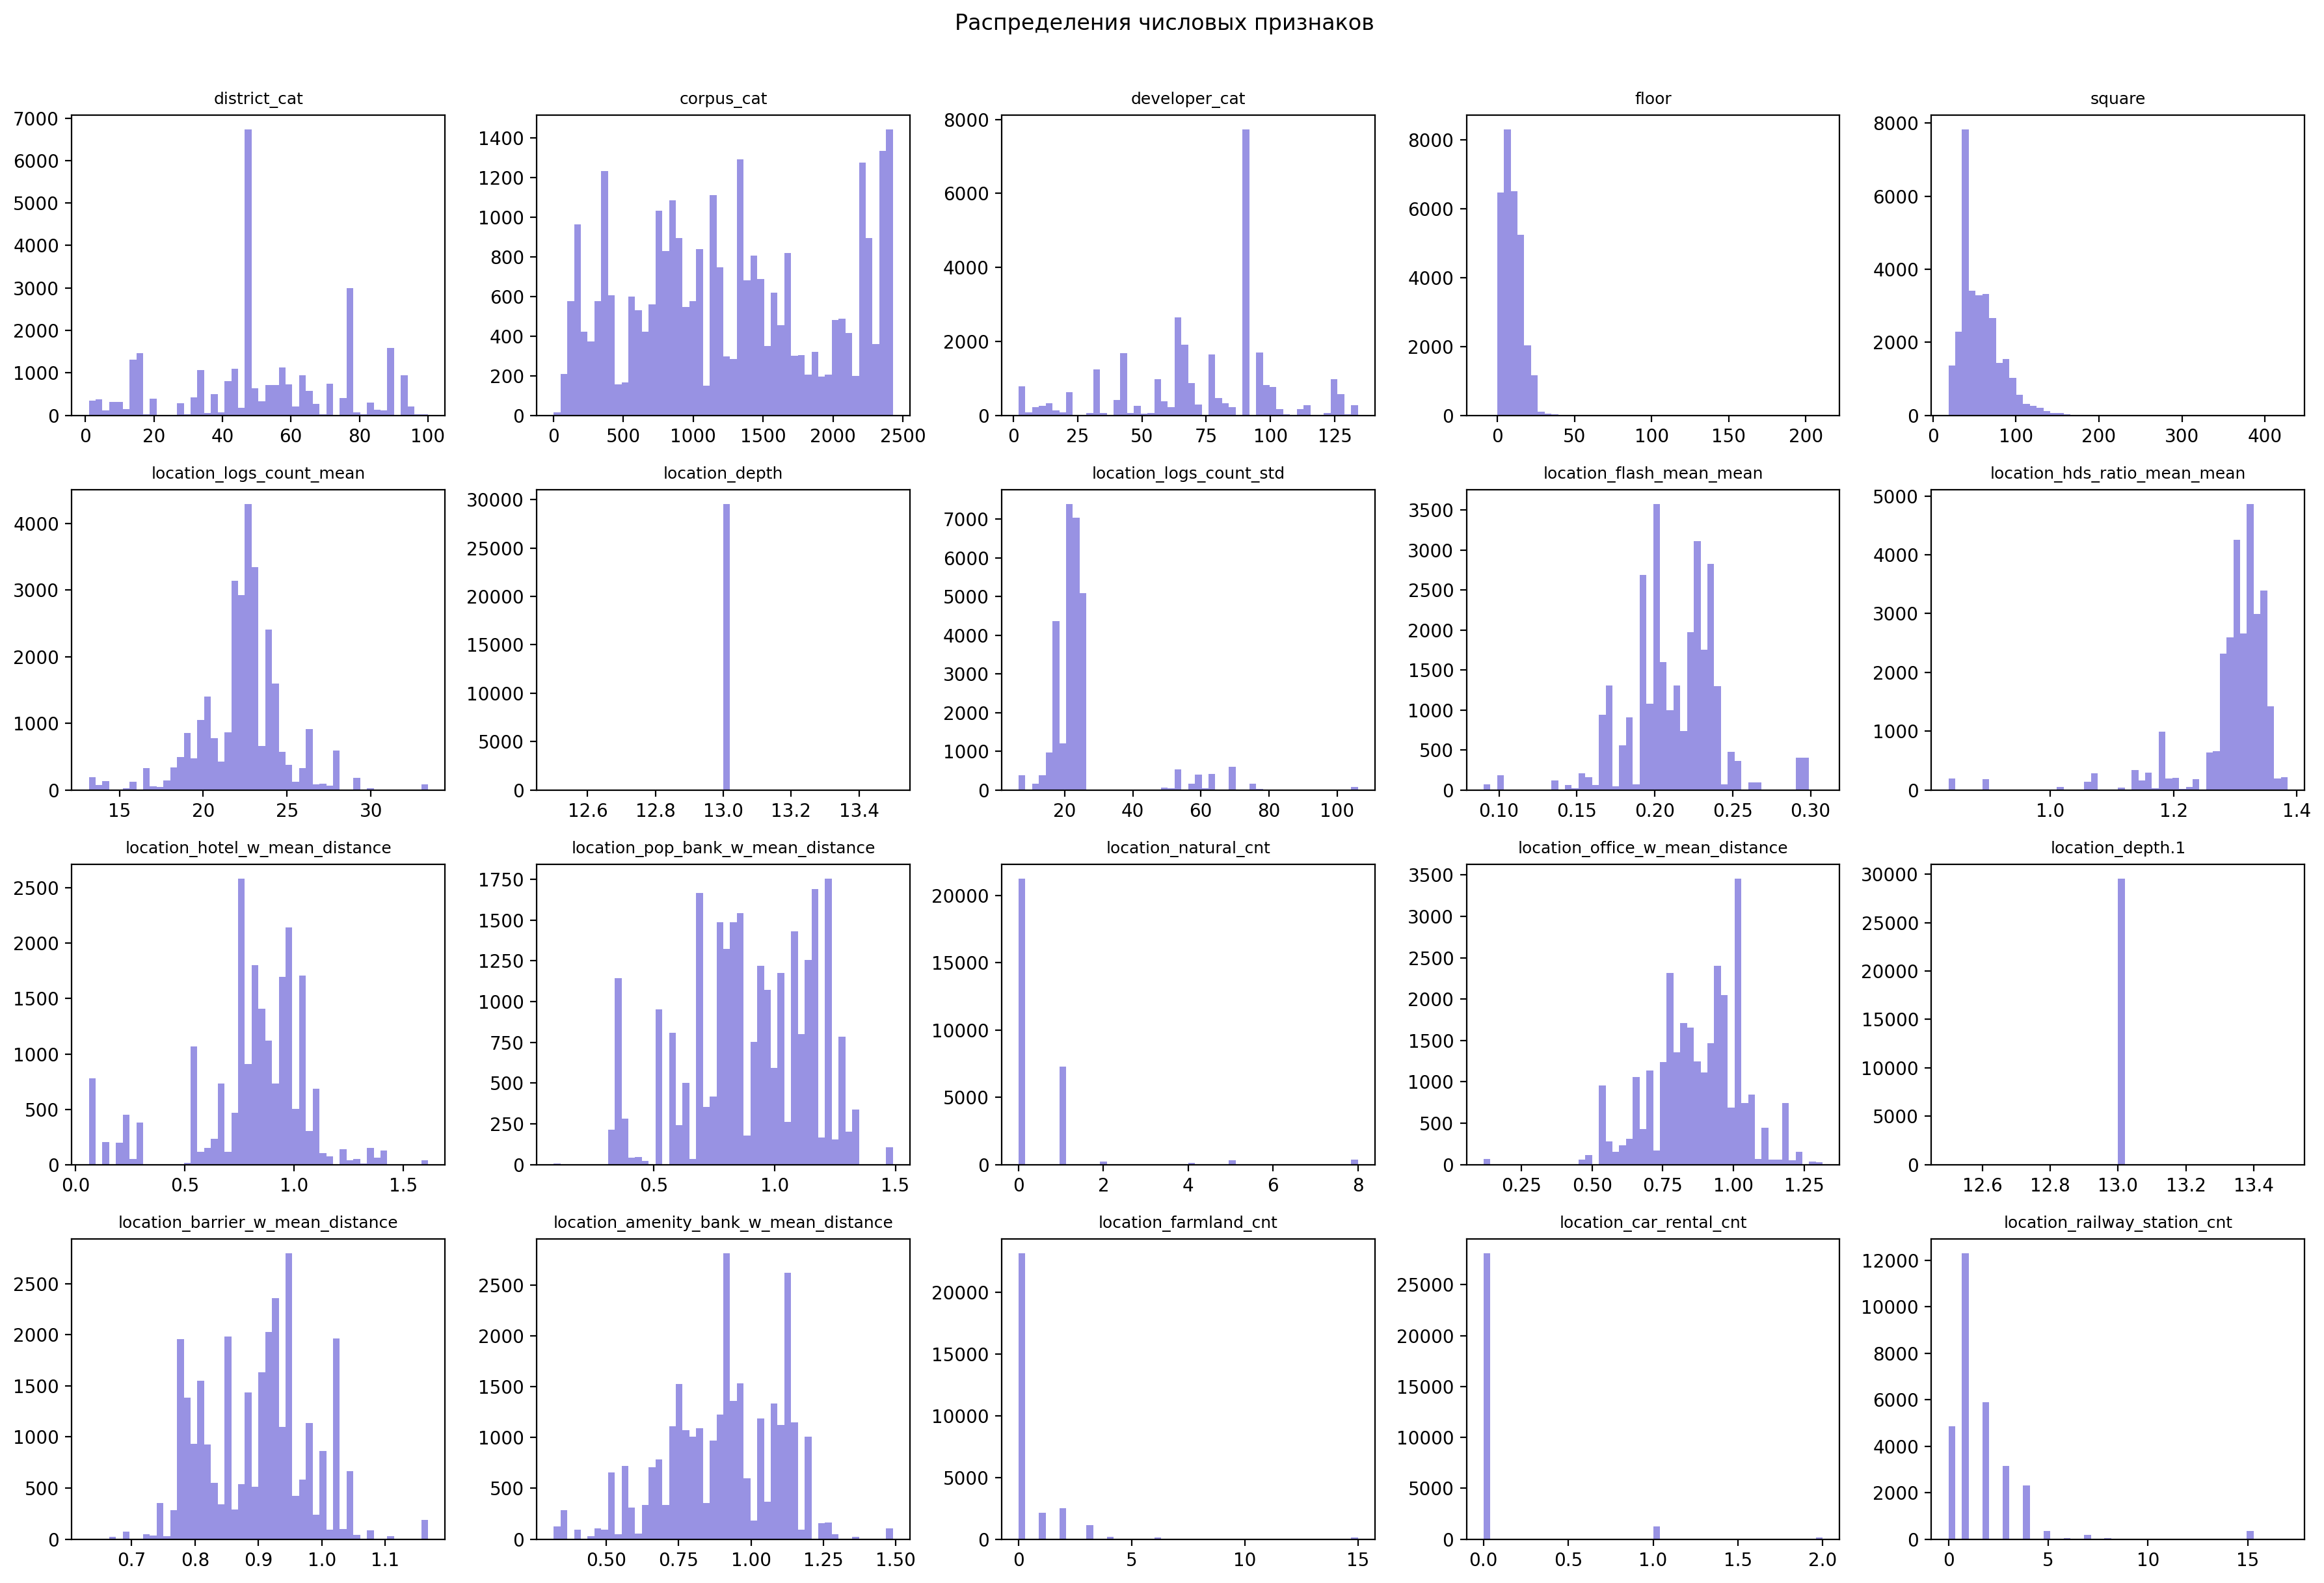

In [33]:
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'price_target']

data_clean = data.replace(-999, np.nan)

cols_to_plot = num_cols[:20]
fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    axes[i].hist(data_clean[col].dropna(), bins=50, 
                 color='#7F77DD', edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    
plt.suptitle('Распределения числовых признаков', y=1.01)
plt.tight_layout()
plt.show()

In [34]:
low_variance = []
for col in num_cols:
    top_val_pct = data_clean[col].value_counts(normalize=True).iloc[0]
    if top_val_pct > 0.95:
        low_variance.append((col, top_val_pct))
        
print("Почти константные признаки:")
for col, pct in sorted(low_variance, key=lambda x: -x[1]):
    print(f"  {col}: {pct:.1%} одно значение")

Почти константные признаки:
  location_depth: 100.0% одно значение
  location_depth.1: 100.0% одно значение
  location_depth.2: 100.0% одно значение
  location_motel_cnt: 99.6% одно значение
  location_car_rental_cnt: 95.1% одно значение


In [2]:

data_path = r'/home/alexandra/Документы/ml_practice/datasets/hw_interpretation/data.csv'
data = pd.read_csv(data_path, sep=',')

data = data.replace(-999, np.nan)

cols_to_drop = []
for col in data.select_dtypes(include=[np.number]).columns:
    if col == 'price_target':
        continue
    if data[col].value_counts(normalize=True).iloc[0] >= 0.95:
        cols_to_drop.append(col)
data = data.drop(columns=cols_to_drop)

data['region_name_cat'] = data['region_name_cat'].replace('Область', 'Пригород')
data['region_encoded']  = data['region_name_cat'].map({'Город': 1, 'Пригород': 0})
data['rooms_numeric']   = data['rooms_4'].map(
    {'студия': 0.5, '1': 1.0, '2': 2.0, '3': 3.0, '>=4': 4.0}
)

p99  = data['price_target'].quantile(0.99)
data = data[data['price_target'] <= p99].copy()

numeric_columns = data.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns = [c for c in numeric_columns if c != 'price_target']

data_model = data[numeric_columns + ['price_target']].copy()
for col in numeric_columns:
    data_model[col] = data_model[col].fillna(data_model[col].median())

print(f"\nРазмер: {data_model.shape}")
print(f"Цена: min={data_model['price_target'].min():.0f}, "
      f"max={data_model['price_target'].max():.0f}, "
      f"median={data_model['price_target'].median():.0f}")


Размер: (29605, 77)
Цена: min=15859, max=63076, median=22158


In [38]:
X = data_model[numeric_columns]
y = data_model['price_target'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (23684, 76)
Test:  (5921, 76)


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

In [4]:
scaler_std     = StandardScaler()
X_train_scaled = scaler_std.fit_transform(X_train)
X_test_scaled  = scaler_std.transform(X_test)

datasets = {
    'без нормализации': (X_train.values, X_test.values),
    'с нормализацией':  (X_train_scaled, X_test_scaled),
}

def mape(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) / np.abs(y_true)) * 100

def calculate_metrics(y_true, y_pred):
    mse  = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    return {'MSE': round(mse, 2), 'RMSE': round(rmse, 2),
            'MAPE': round(mape(y_true, y_pred), 2)}

model_templates = {
    'LinearRegression': LinearRegression(),
    'Lasso':            Lasso(alpha=0.001, max_iter=5000, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(
                            max_depth=5, n_estimators=100, random_state=42),
}

results        = {}
trained_models = {}

for ds_name, (X_tr, X_te) in datasets.items():
    for m_name, template in model_templates.items():
        model = copy.deepcopy(template)
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        key    = f"{m_name} | {ds_name}"
        results[key]        = calculate_metrics(y_test.values, y_pred)
        trained_models[key] = model

## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

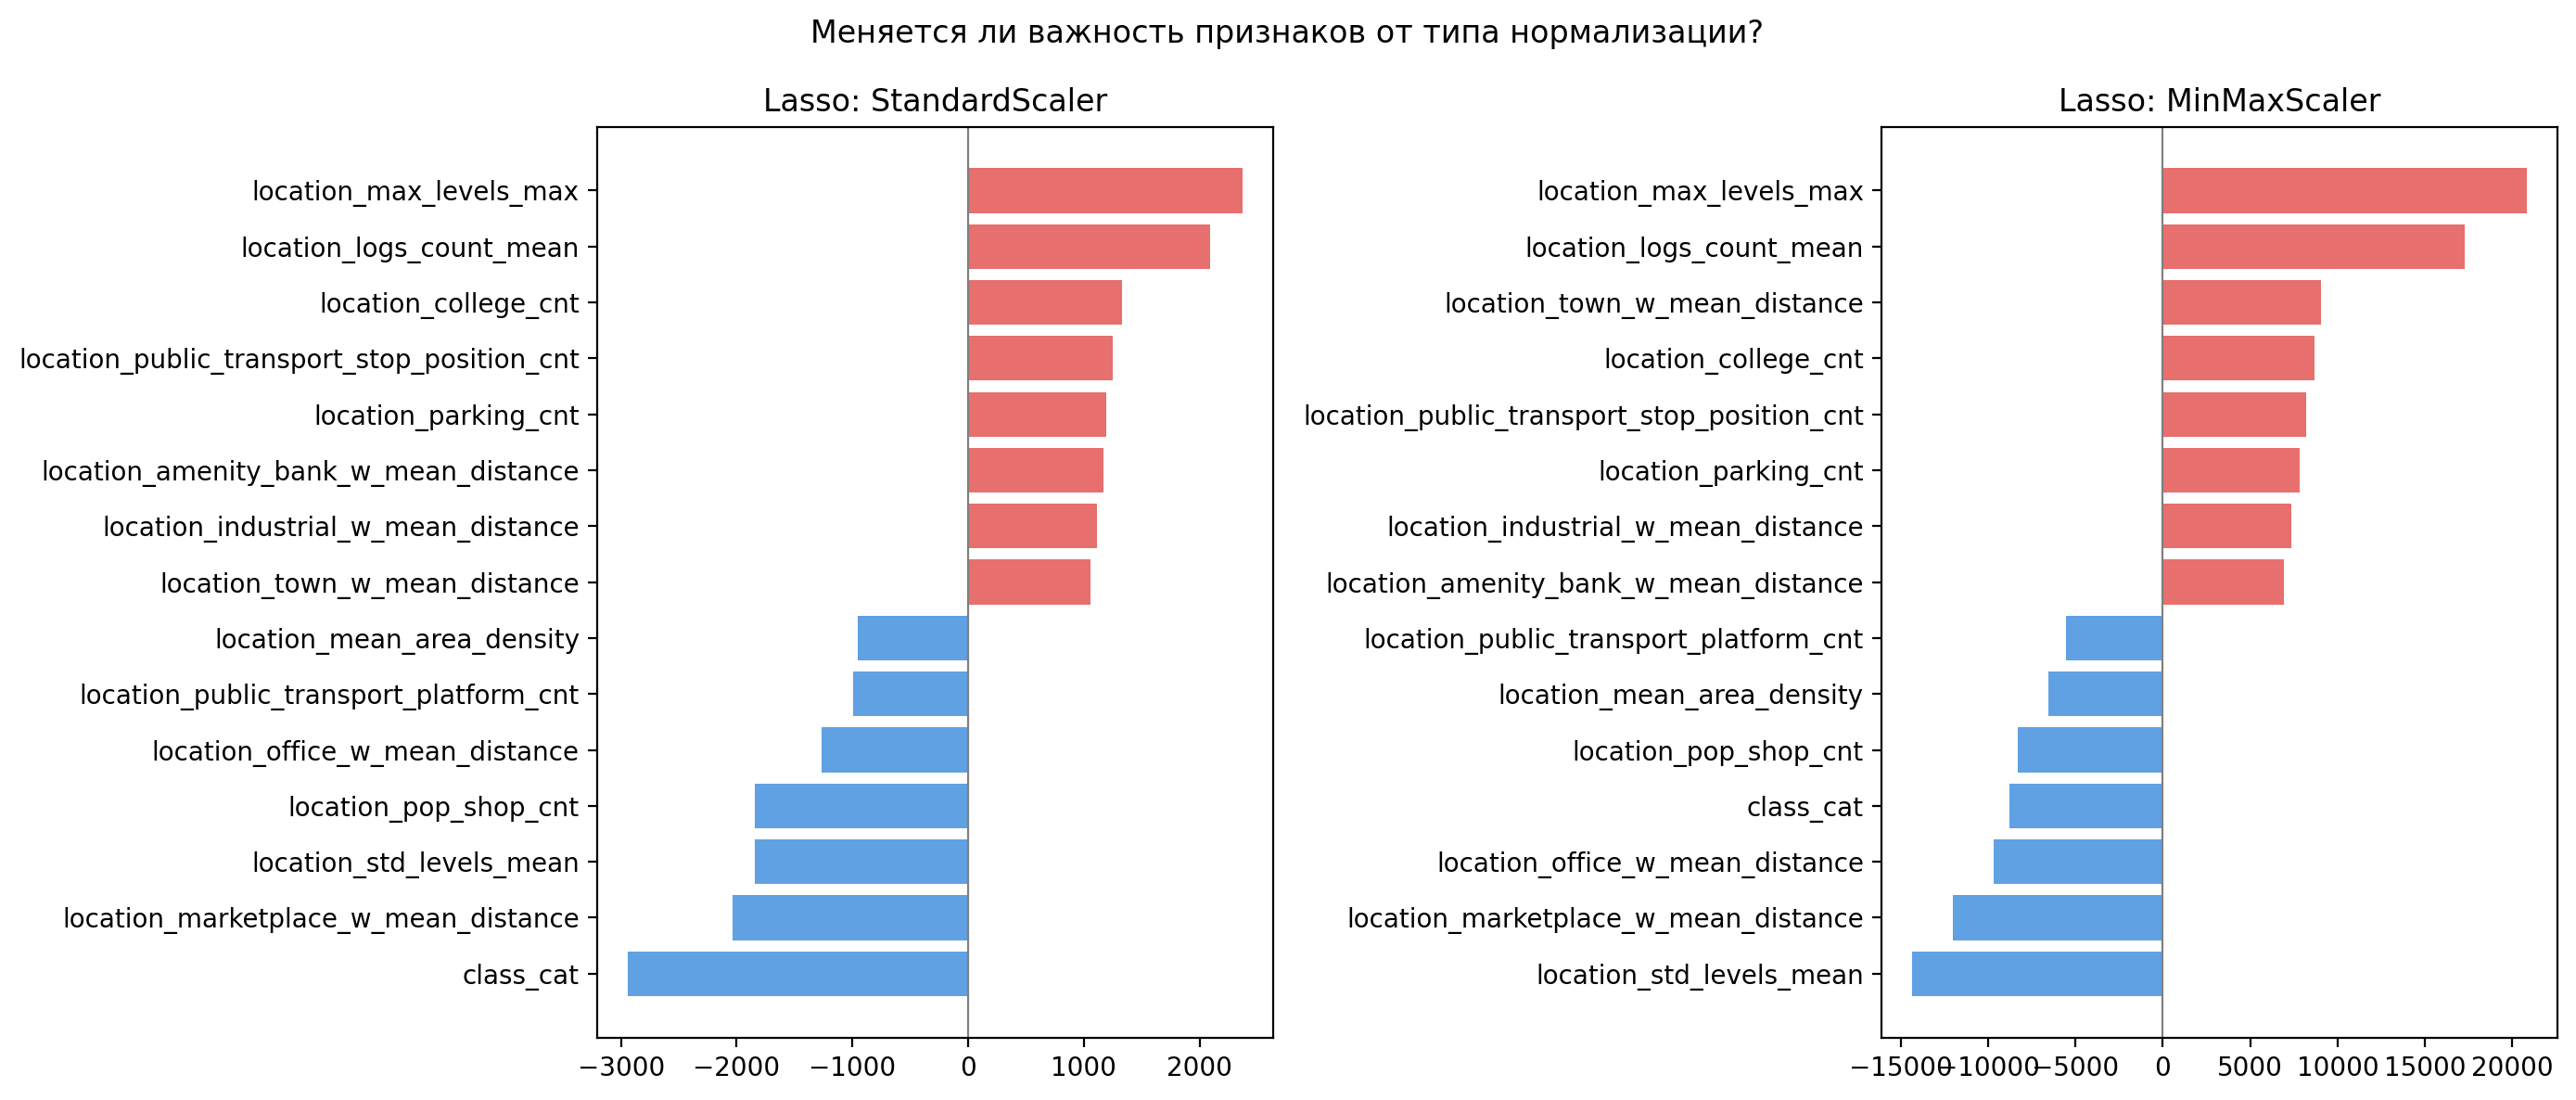

In [5]:
scaler_mm  = MinMaxScaler()
scaler_std2 = StandardScaler()

lasso_mm  = Lasso(alpha=0.001, max_iter=5000, random_state=42)
lasso_std = Lasso(alpha=0.001, max_iter=5000, random_state=42)

lasso_mm.fit(scaler_mm.fit_transform(X_train),   y_train)
lasso_std.fit(scaler_std2.fit_transform(X_train), y_train)

coef_mm  = pd.Series(lasso_mm.coef_,  index=numeric_columns)
coef_std = pd.Series(lasso_std.coef_, index=numeric_columns)

top15 = coef_std.abs().sort_values(ascending=False).head(15).index

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coef, title in zip(
    axes,
    [coef_std[top15].sort_values(), coef_mm[top15].sort_values()],
    ['StandardScaler', 'MinMaxScaler']
):
    colors = ['#E24B4A' if v > 0 else '#378ADD' for v in coef]
    ax.barh(coef.index, coef.values, color=colors, alpha=0.8)
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_title(f'Lasso: {title}')
plt.suptitle('Меняется ли важность признаков от типа нормализации?')
plt.tight_layout()
plt.show()

from scipy.stats import spearmanr
corr, _ = spearmanr(coef_std[top15].abs(), coef_mm[top15].abs())

## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

In [6]:
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm  = scaler_mm.transform(X_test)

X_train_mm_df = pd.DataFrame(X_train_mm, columns=numeric_columns, index=X_train.index)
X_test_mm_df  = pd.DataFrame(X_test_mm,  columns=numeric_columns, index=X_test.index)

linear_model   = LinearRegression().fit(X_train_mm, y_train)
boosting_model = GradientBoostingRegressor(
    max_depth=5, n_estimators=100, random_state=42
).fit(X_train_mm, y_train)

print("Модели обучены на MinMaxScaler")
print(f"  Linear:   MAPE = {mape(y_test, linear_model.predict(X_test_mm)):.2f}%")
print(f"  Boosting: MAPE = {mape(y_test, boosting_model.predict(X_test_mm)):.2f}%")

Модели обучены на MinMaxScaler
  Linear:   MAPE = 9.20%
  Boosting: MAPE = 4.04%


Признак: rooms_numeric
Диапазон в train: [0.5, 4.0]


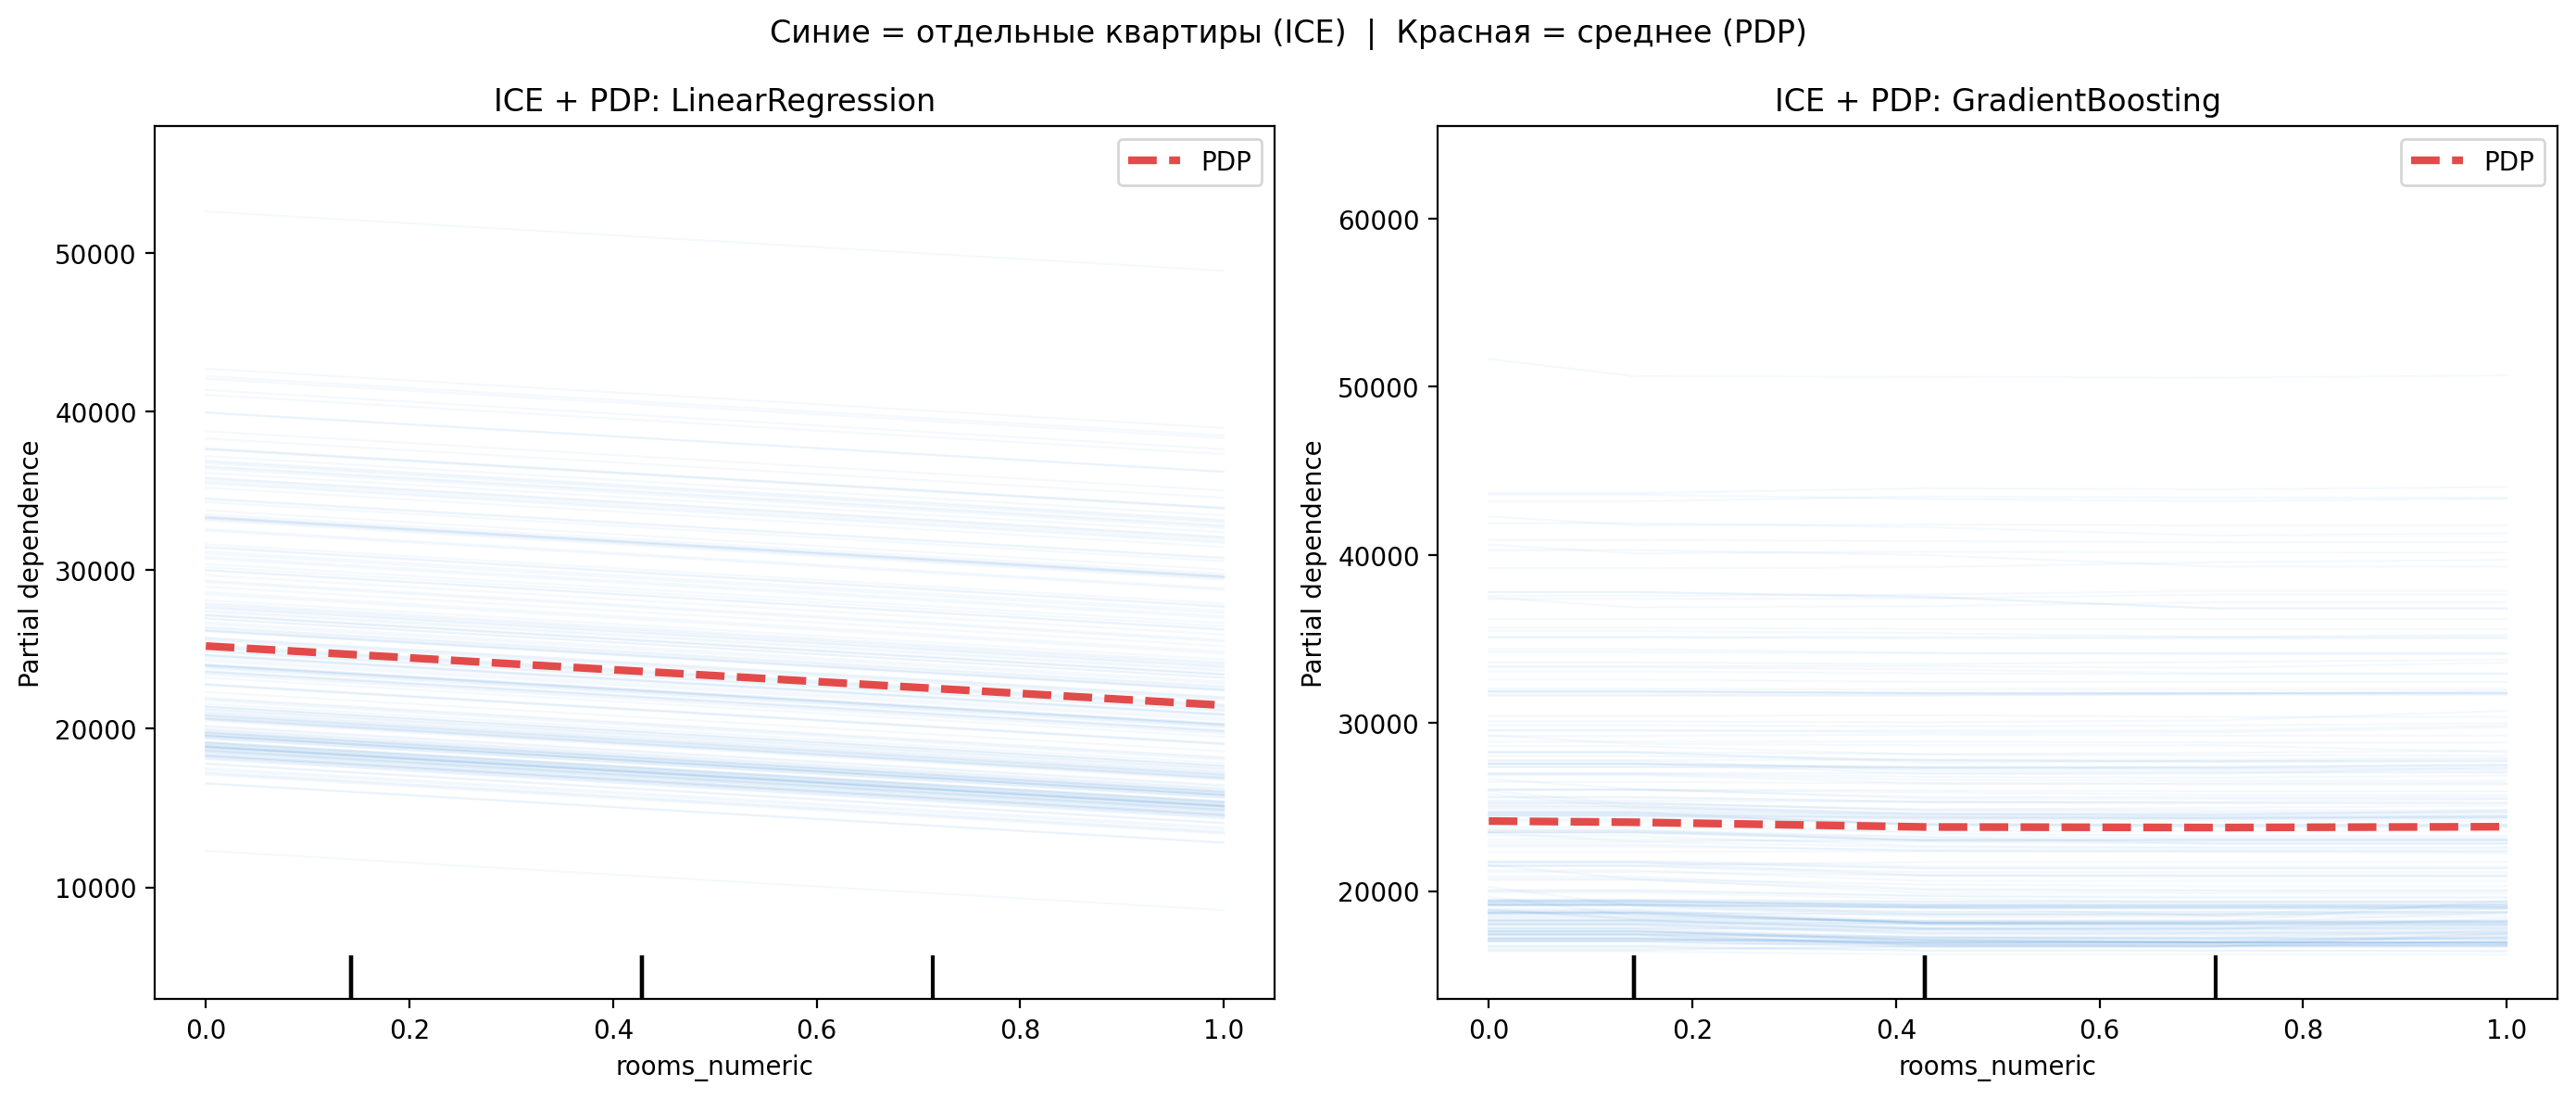

In [7]:
FEATURE     = 'rooms_numeric'
FEATURE_IDX = numeric_columns.index(FEATURE)
train_min   = X_train[FEATURE].min()
train_max   = X_train[FEATURE].max()

print(f"Признак: {FEATURE}")
print(f"Диапазон в train: [{train_min:.1f}, {train_max:.1f}]")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, name in zip(
    axes,
    [linear_model,   boosting_model],
    ['LinearRegression', 'GradientBoosting']
):
    PartialDependenceDisplay.from_estimator(
        estimator=model,
        X=X_train_mm_df,
        features=[FEATURE],
        kind='both',
        subsample=200,
        random_state=42,
        ax=ax,
        ice_lines_kw={'color': '#378ADD', 'alpha': 0.05, 'linewidth': 0.8},
        pd_line_kw={'color': '#E24B4A', 'linewidth': 3, 'label': 'PDP'}
    )
    ticks = [0.0, 0.25, 0.5, 0.75, 1.0]
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{train_min + t*(train_max-train_min):.0f}" for t in ticks])
    ax.set_xlabel(f'{FEATURE} (м²)')
    ax.set_ylabel('Предсказание (руб/м²)')
    ax.set_title(f'ICE + PDP: {name}')
    ax.legend(fontsize=9)

plt.suptitle('Синие = отдельные квартиры (ICE)  |  Красная = среднее (PDP)')
plt.tight_layout()
plt.show()

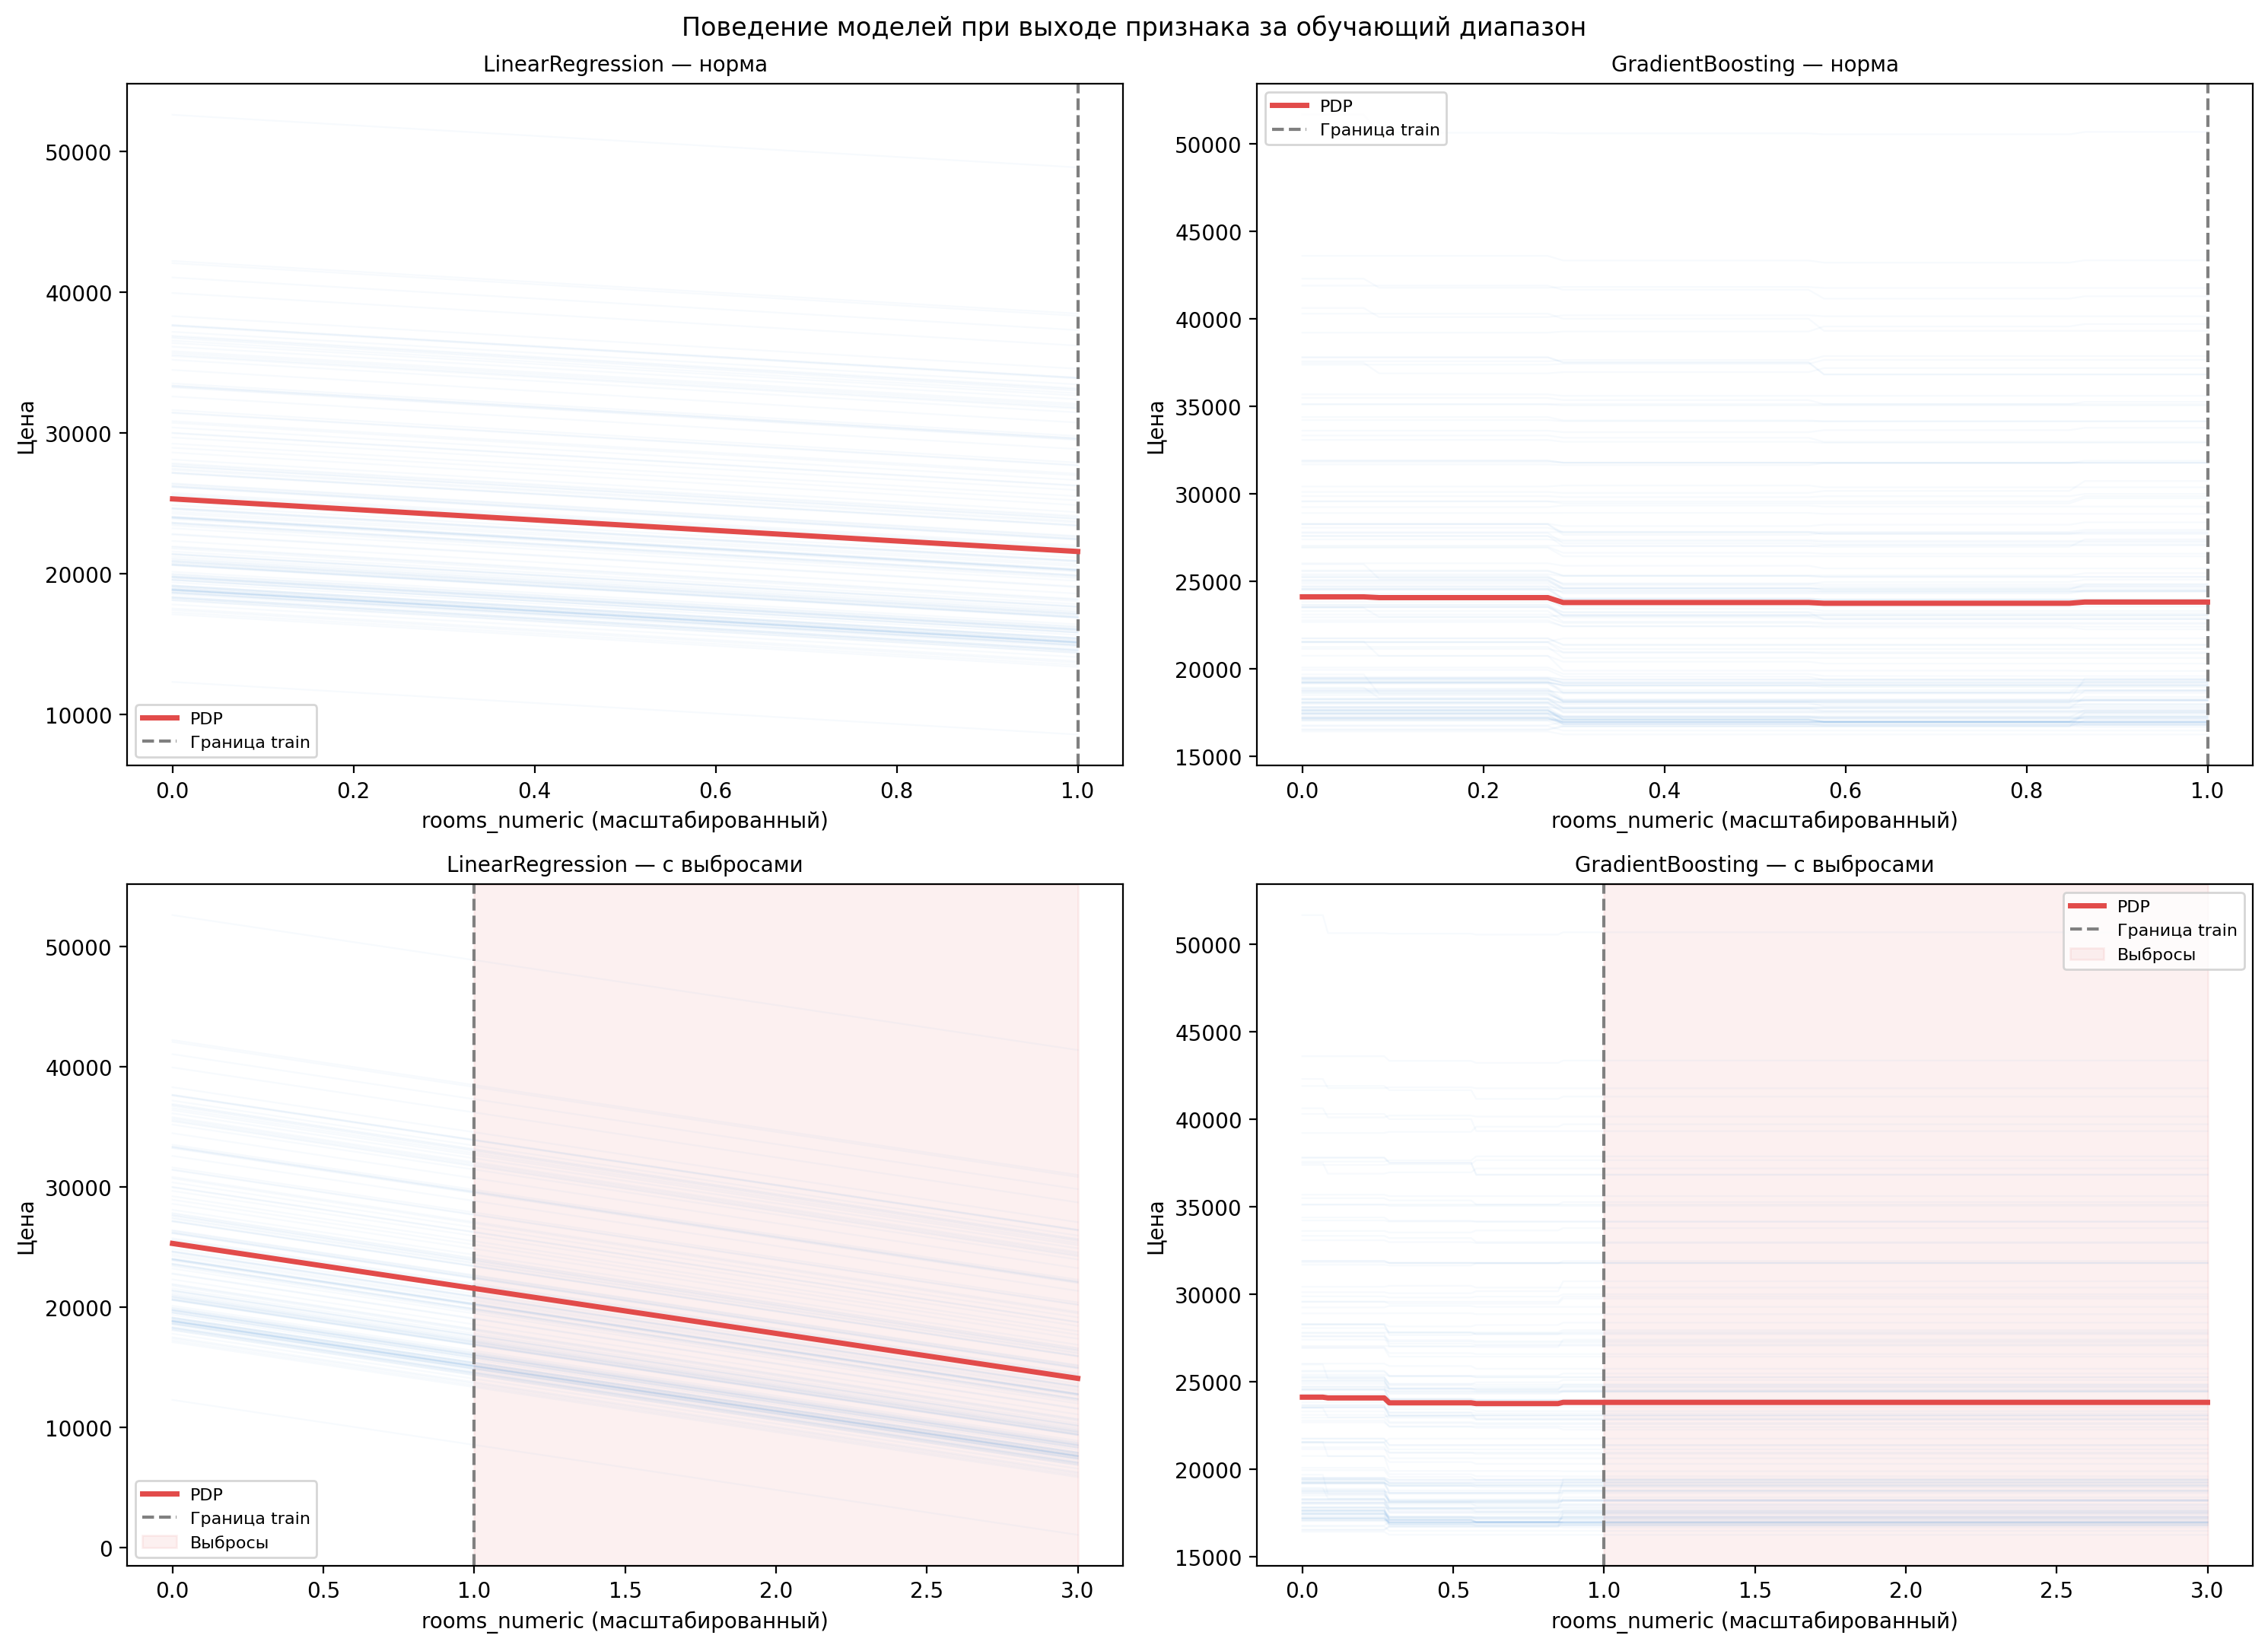

In [8]:
def compute_ice_pdp(model, X_arr, feat_idx, grid, n_obj=150, seed=42):
    np.random.seed(seed)
    idx   = np.random.choice(len(X_arr), size=min(n_obj, len(X_arr)), replace=False)
    X_sub = X_arr[idx].copy()
    ice   = np.zeros((len(idx), len(grid)))
    for g_i, g_val in enumerate(grid):
        X_mod              = X_sub.copy()
        X_mod[:, feat_idx] = g_val
        ice[:, g_i]        = model.predict(X_mod)
    return ice, ice.mean(axis=0)

grid_normal   = np.linspace(0.0, 1.0, 60)
grid_extended = np.concatenate([grid_normal, np.linspace(1.0, 3.0, 30)])

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

configs = [
    (axes[0,0], linear_model,   grid_normal,   'LinearRegression — норма'),
    (axes[0,1], boosting_model, grid_normal,   'GradientBoosting — норма'),
    (axes[1,0], linear_model,   grid_extended, 'LinearRegression — с выбросами'),
    (axes[1,1], boosting_model, grid_extended, 'GradientBoosting — с выбросами'),
]

for ax, model, grid, title in configs:
    ice, pdp = compute_ice_pdp(model, X_train_mm, FEATURE_IDX, grid)
    for i in range(ice.shape[0]):
        ax.plot(grid, ice[i], color='#378ADD', alpha=0.04, linewidth=0.8)
    ax.plot(grid, pdp, color='#E24B4A', linewidth=2.5, label='PDP', zorder=5)
    ax.axvline(1.0, color='gray', linestyle='--', linewidth=1.5, label='Граница train')
    if grid.max() > 1.0:
        ax.axvspan(1.0, grid.max(), alpha=0.08, color='#E24B4A', label='Выбросы')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(f'{FEATURE} (масштабированный)')
    ax.set_ylabel('Цена')
    ax.legend(fontsize=8)

plt.suptitle('Поведение моделей при выходе признака за обучающий диапазон')
plt.tight_layout()
plt.show()


## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

Медиана rooms_numeric: 2.0 -> 0.4286 (scaled)


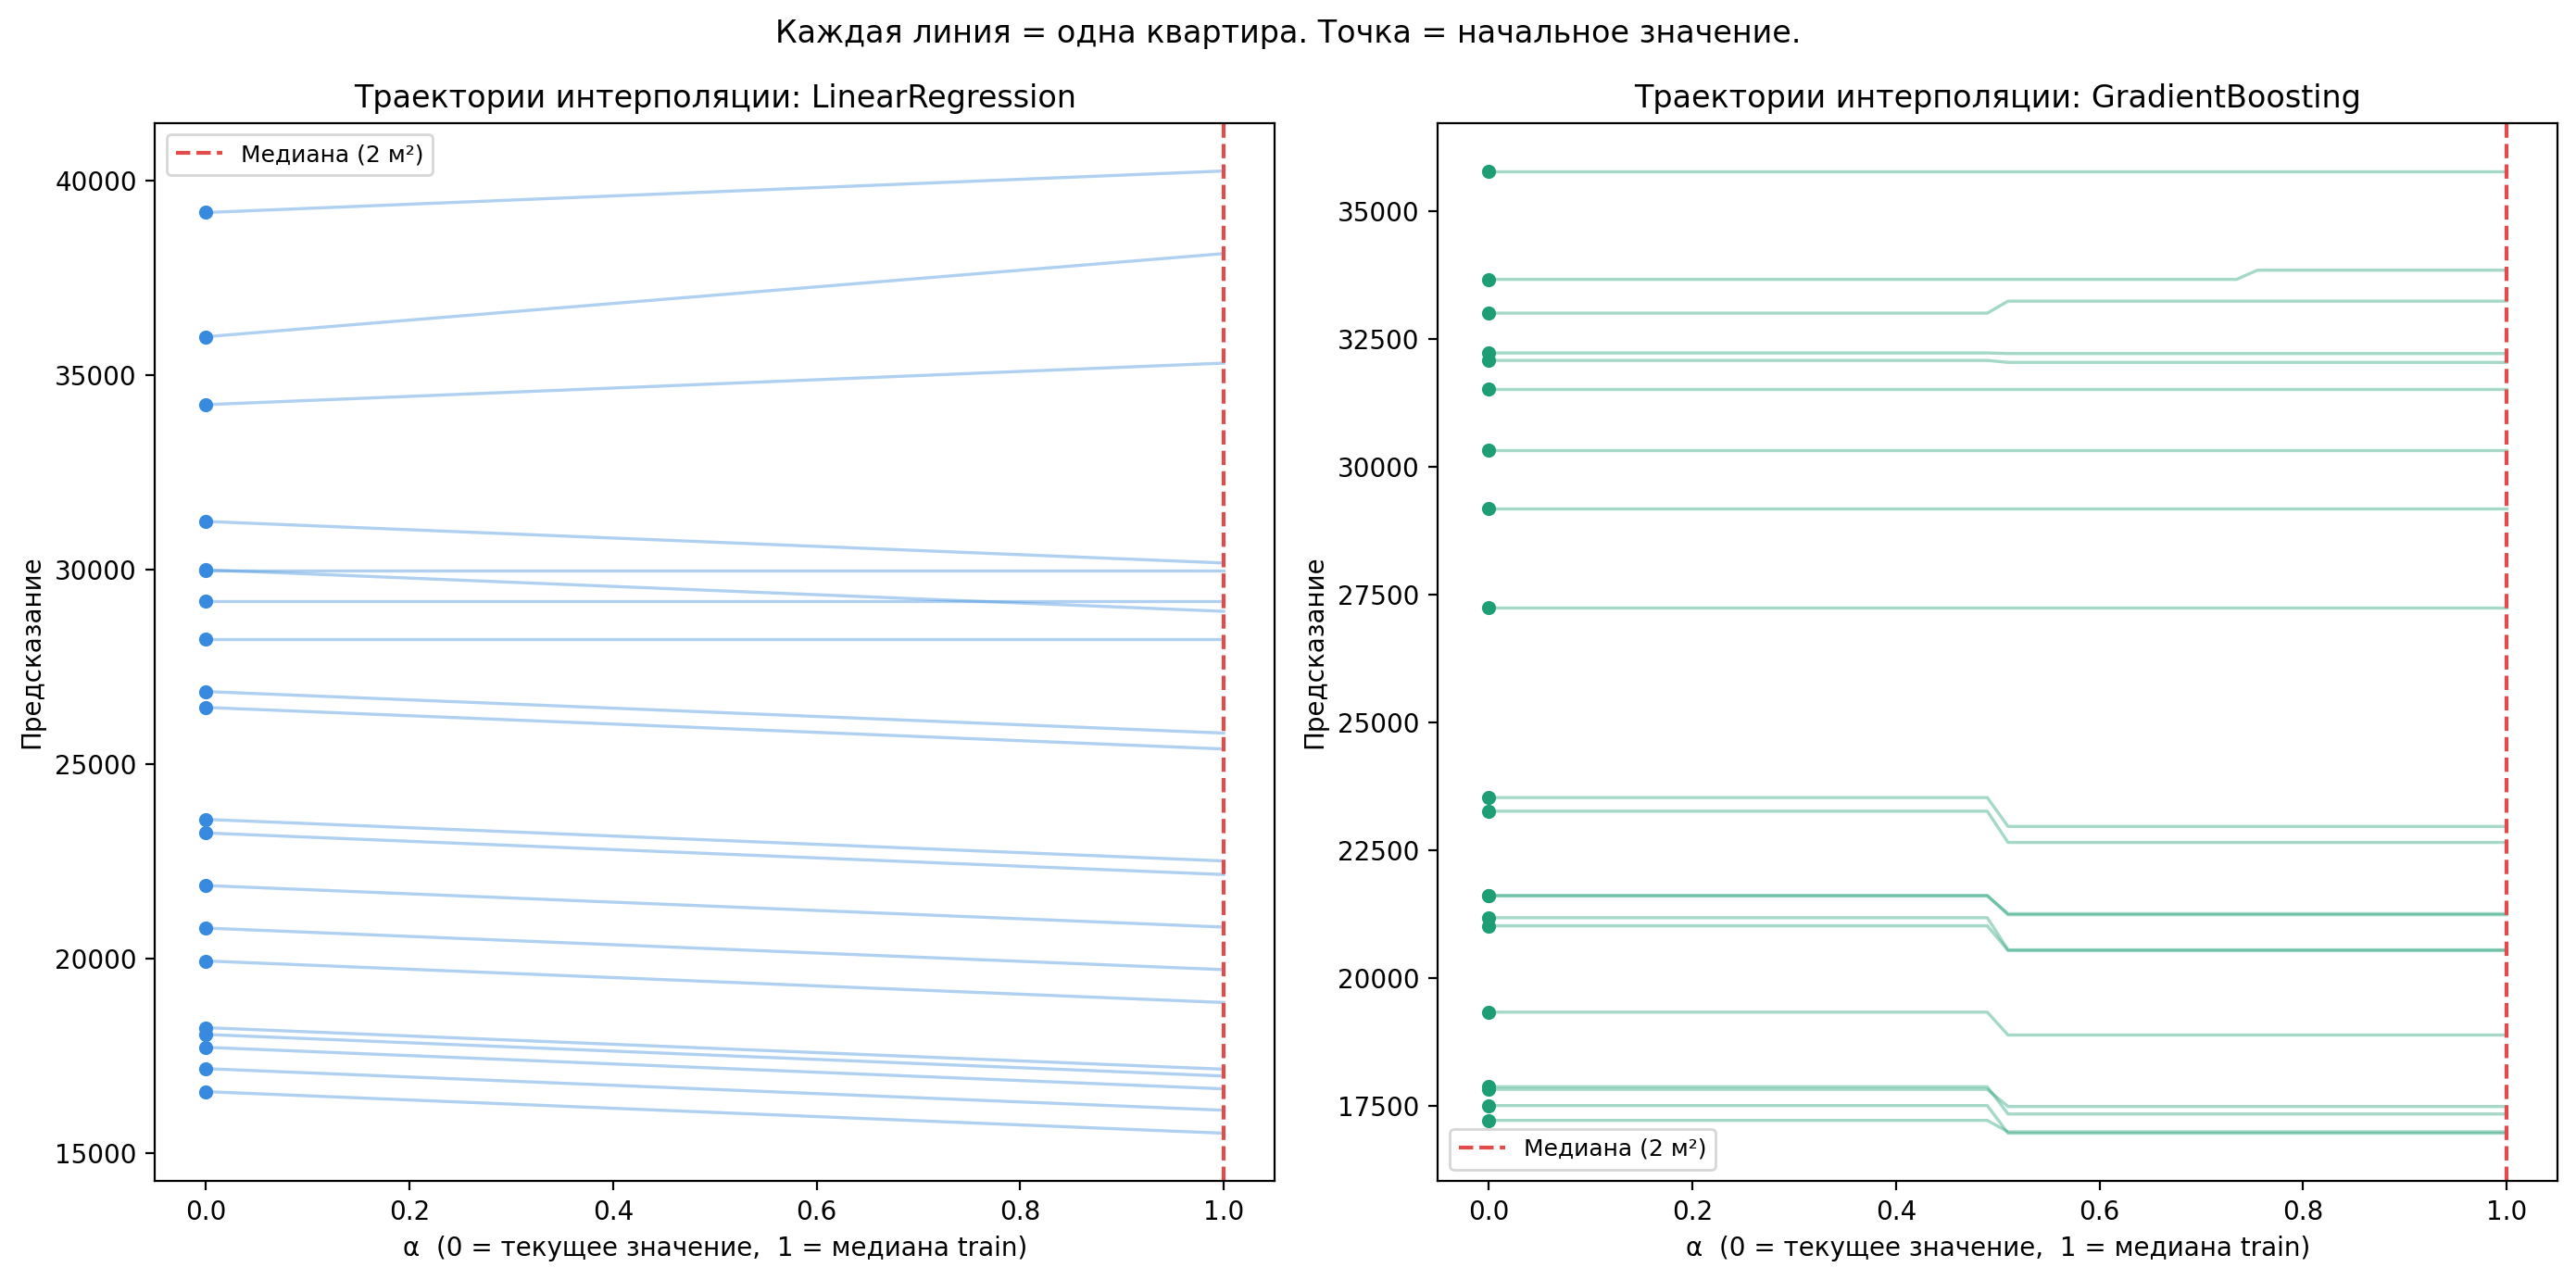

In [ ]:
base_orig = X_train[FEATURE].median()
dummy     = np.zeros((1, len(numeric_columns)))
dummy[0, FEATURE_IDX] = base_orig
base_scaled = scaler_mm.transform(dummy)[0, FEATURE_IDX]

print(f"Медиана {FEATURE}: {base_orig:.1f} -> {base_scaled:.4f} (scaled)")

def compute_trajectory(model, obj_row, feat_idx, base_scaled, n_steps=50):
    alphas = np.linspace(0, 1, n_steps)
    cur    = obj_row[feat_idx]
    preds  = []
    for a in alphas:
        mod             = obj_row.copy()
        mod[feat_idx]   = (1 - a) * cur + a * base_scaled
        preds.append(model.predict(mod.reshape(1, -1))[0])
    return alphas, np.array(preds)

np.random.seed(1)
sel_idx = np.random.choice(len(X_test_mm), size=20, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, model, name, color in zip(
    axes,
    [linear_model,   boosting_model],
    ['LinearRegression', 'GradientBoosting'],
    ["#177213",          "#2CDD23"]
):
    for idx in sel_idx:
        alphas, traj = compute_trajectory(
            model, X_test_mm[idx], FEATURE_IDX, base_scaled
        )
        ax.plot(alphas, traj, color=color, alpha=0.4, linewidth=1.2)
        ax.scatter(alphas[0], traj[0], color=color, s=20, zorder=5)

    ax.axvline(1.0, color='#E24B4A', linestyle='--', linewidth=1.5,
               label=f'Медиана ({base_orig:.0f} м²)')
    ax.set_xlabel('α  (0 = текущее значение,  1 = медиана train)')
    ax.set_ylabel('Предсказание')
    ax.set_title(f'Траектории интерполяции: {name}')
    ax.legend(fontsize=9)

plt.suptitle('Каждая линия = одна квартира. Точка = начальное значение.')
plt.tight_layout()
plt.show()

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

In [10]:
from PyALE import ale
def predict_linear(X_df):
    return linear_model.predict(scaler_mm.transform(X_df))
def predict_boosting(X_df):
    return boosting_model.predict(scaler_mm.transform(X_df))

PyALE._ALE_generic:INFO: Discrete feature detected.


grid_size    Linear ДИ (ср.)      Boosting ДИ (ср.)    объектов/бин
-----------------------------------------------------------------


PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.


5            0.0000               8.2609               (~4737)


PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.


10           0.0000               8.2609               (~2368)


PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.


20           0.0000               8.2609               (~1184)
50           0.0000               8.2609               (~474)


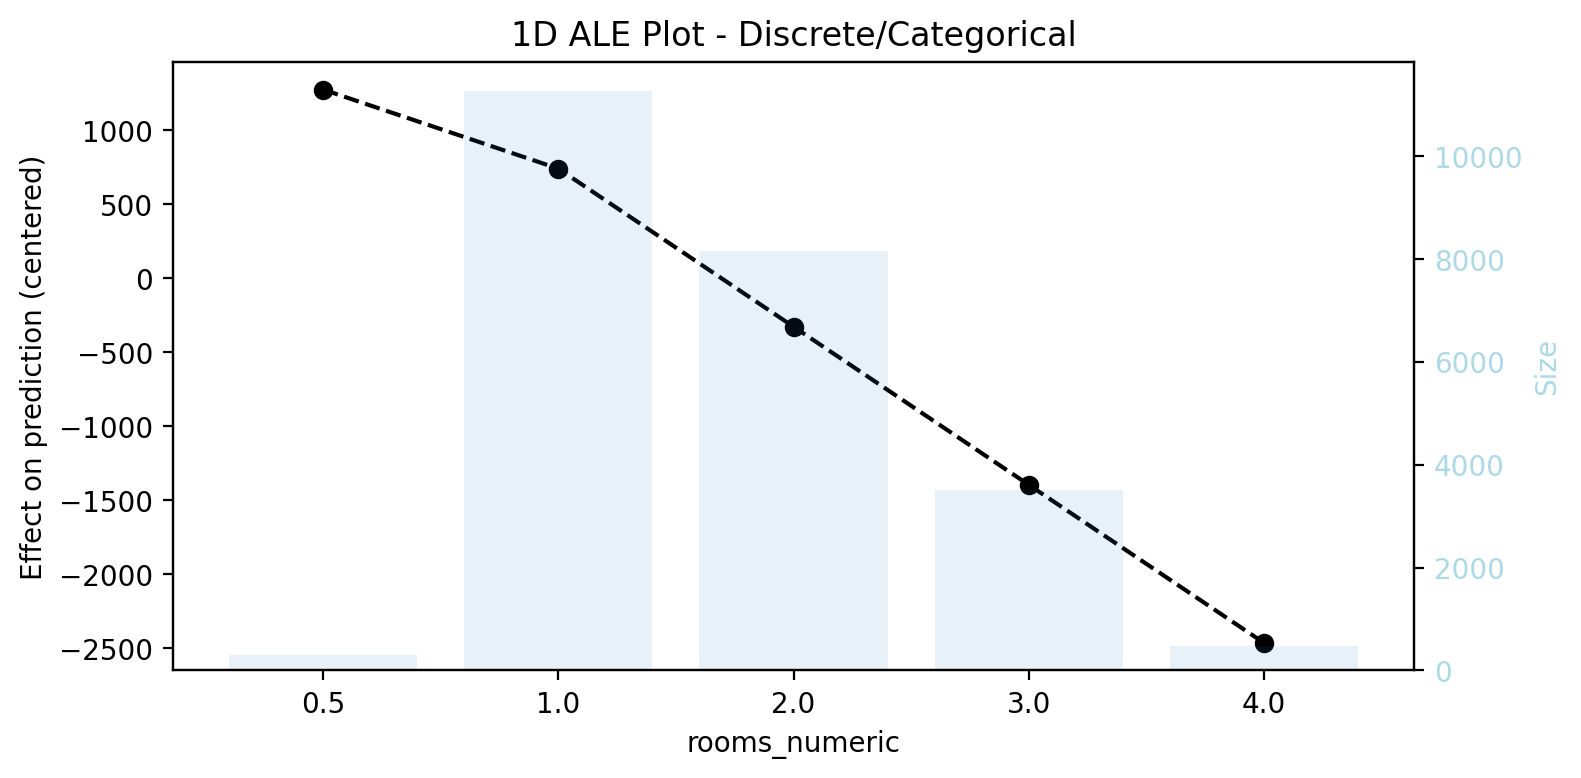

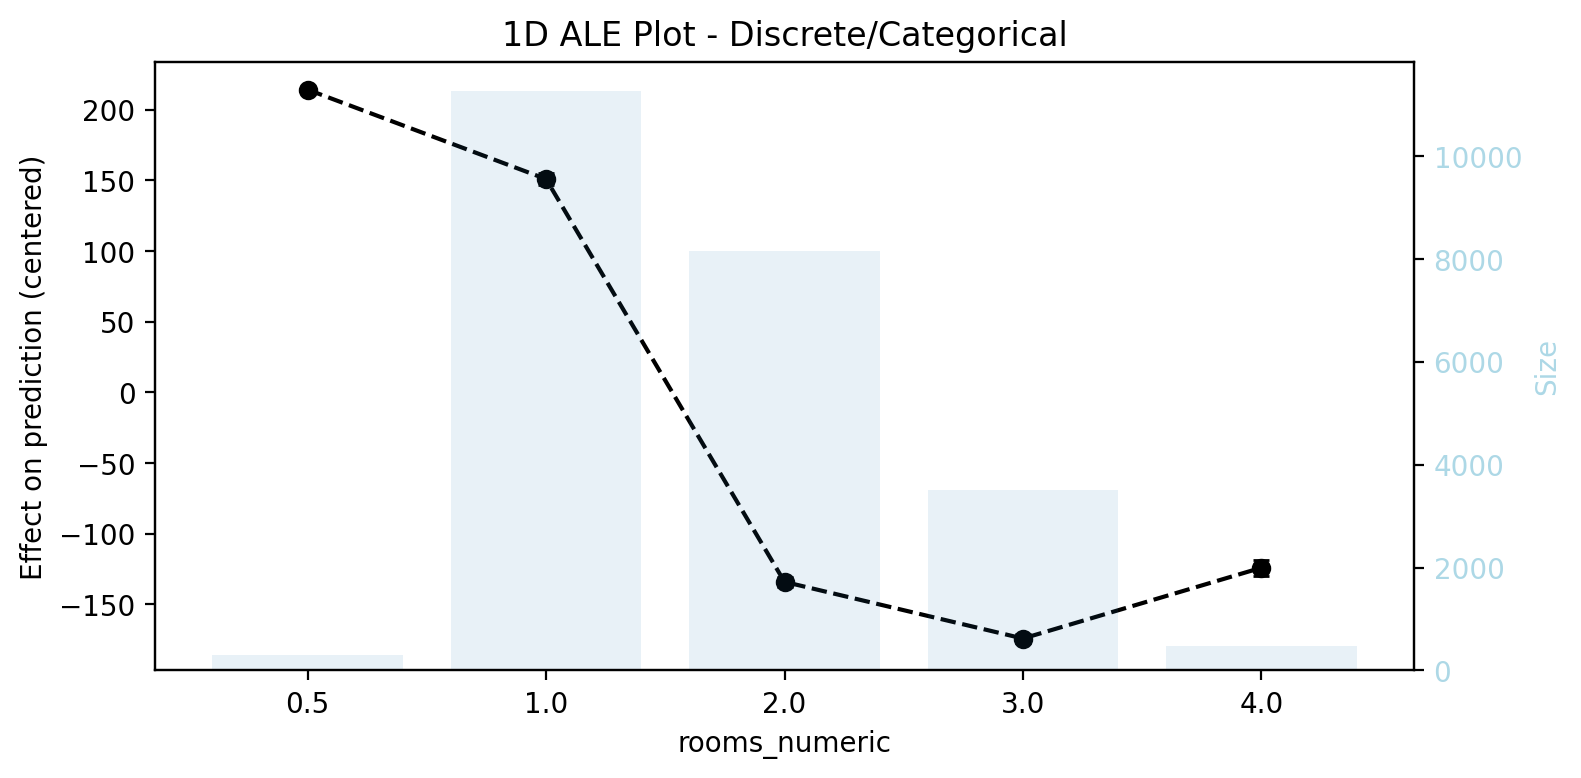

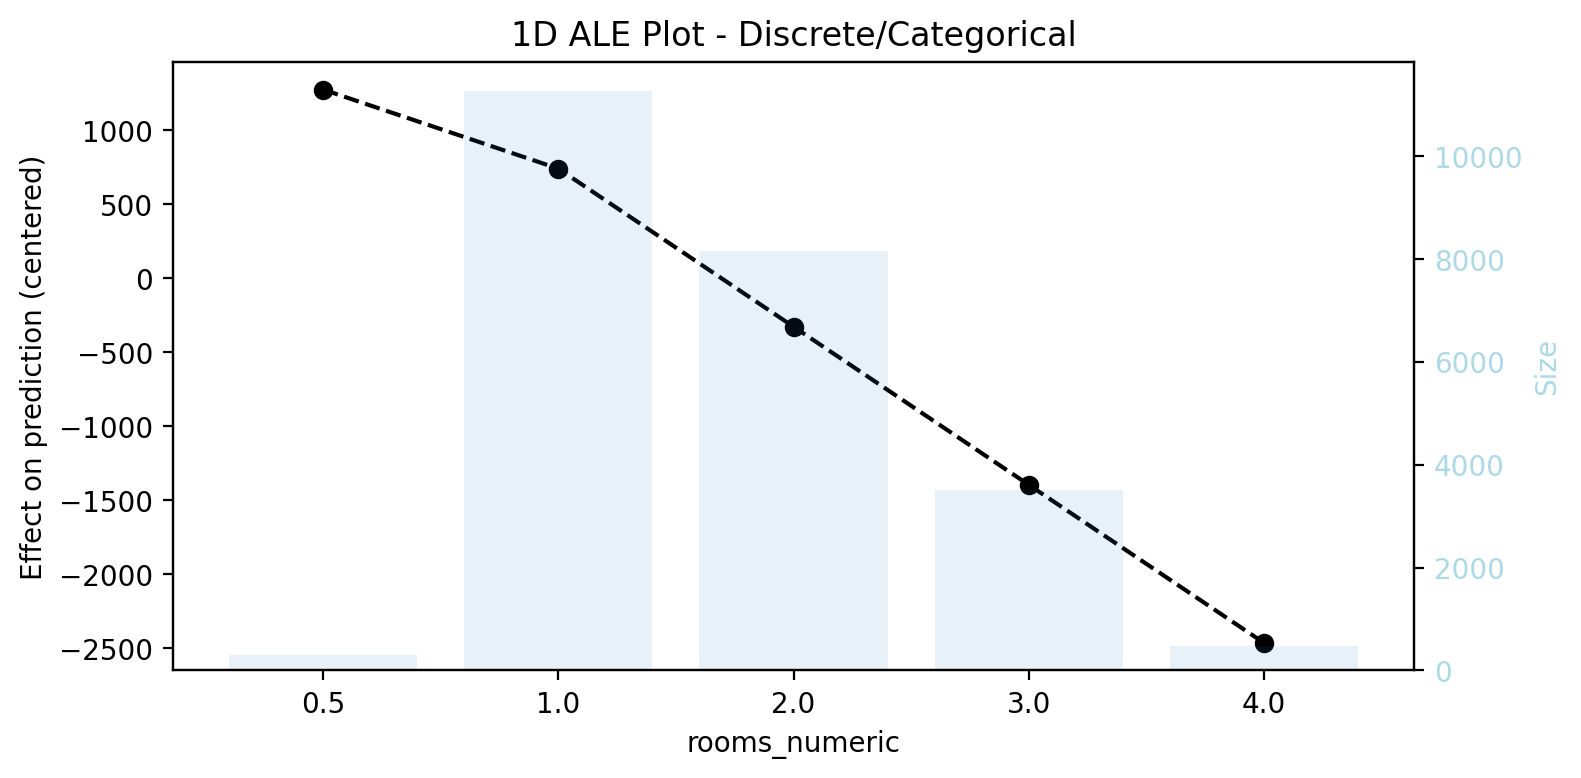

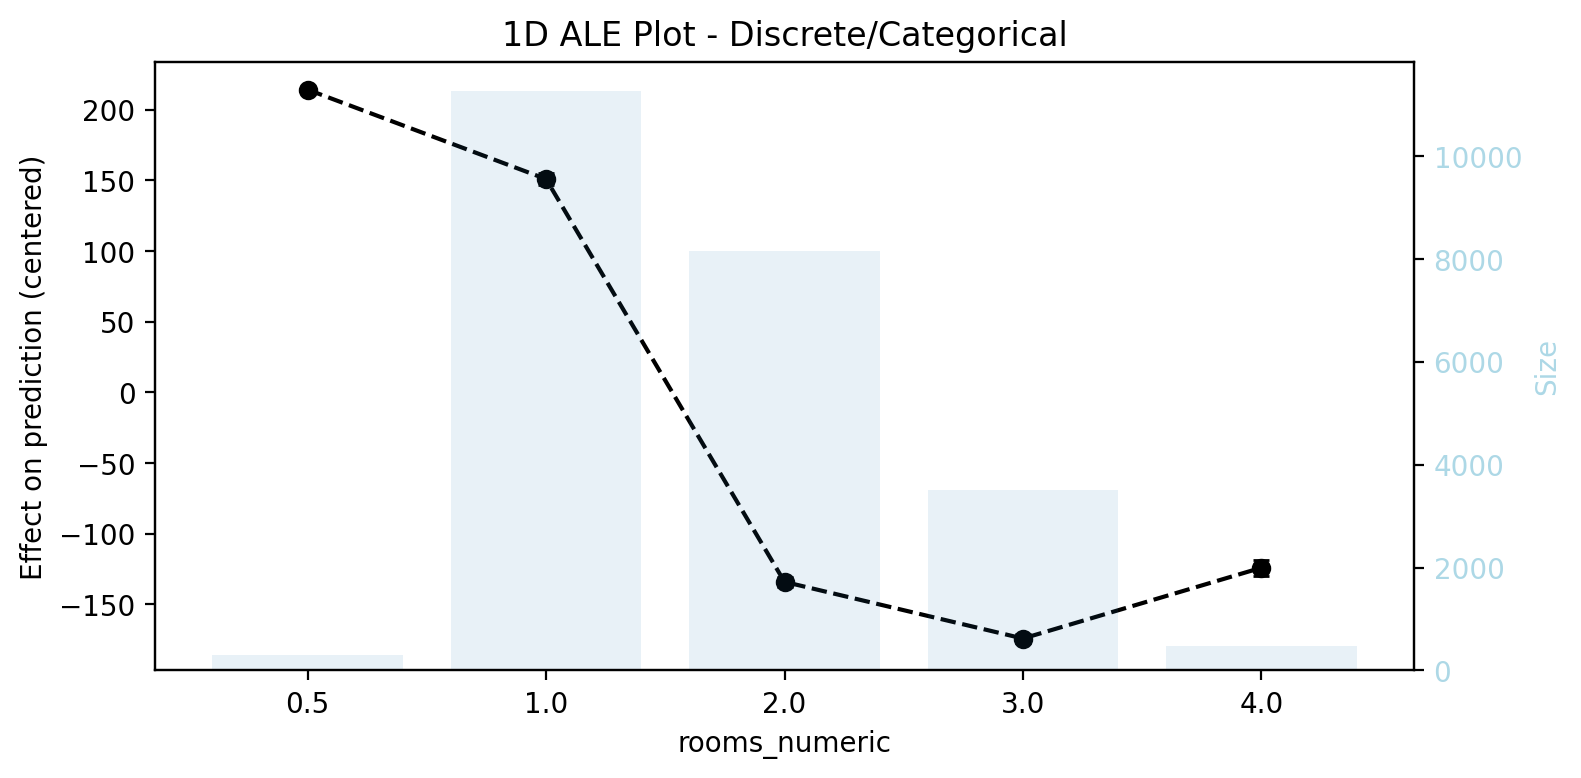

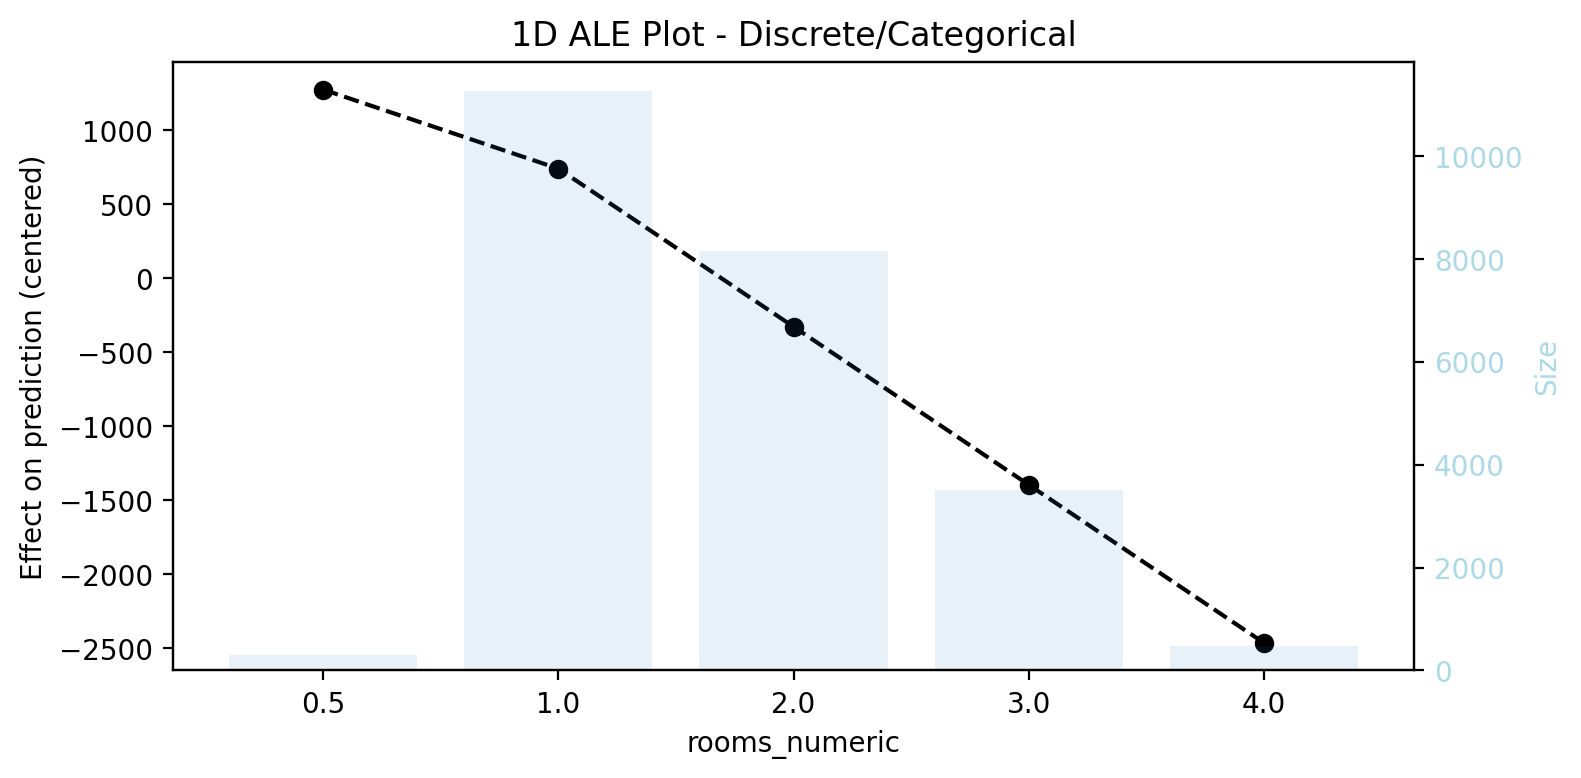

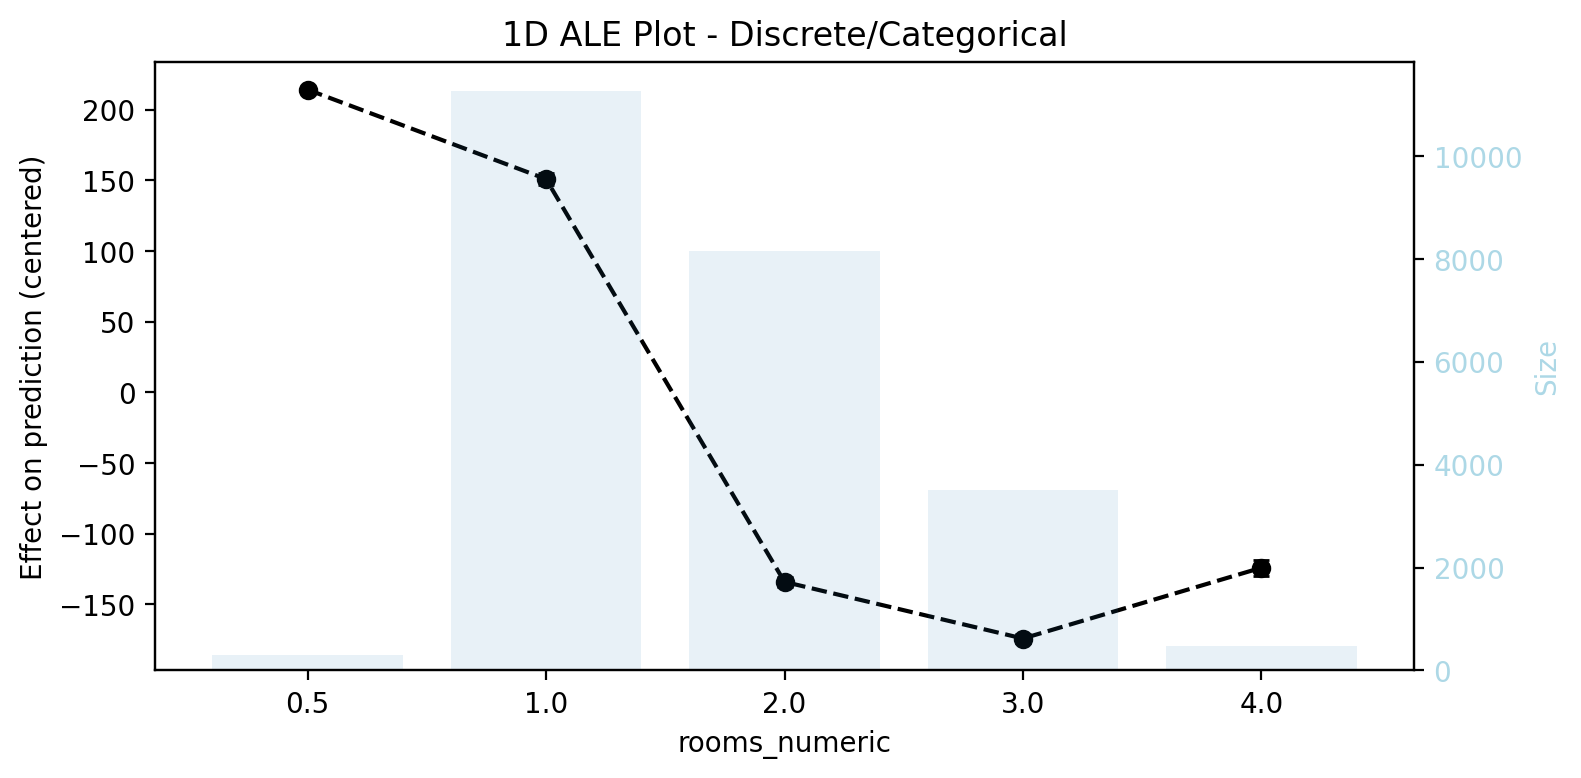

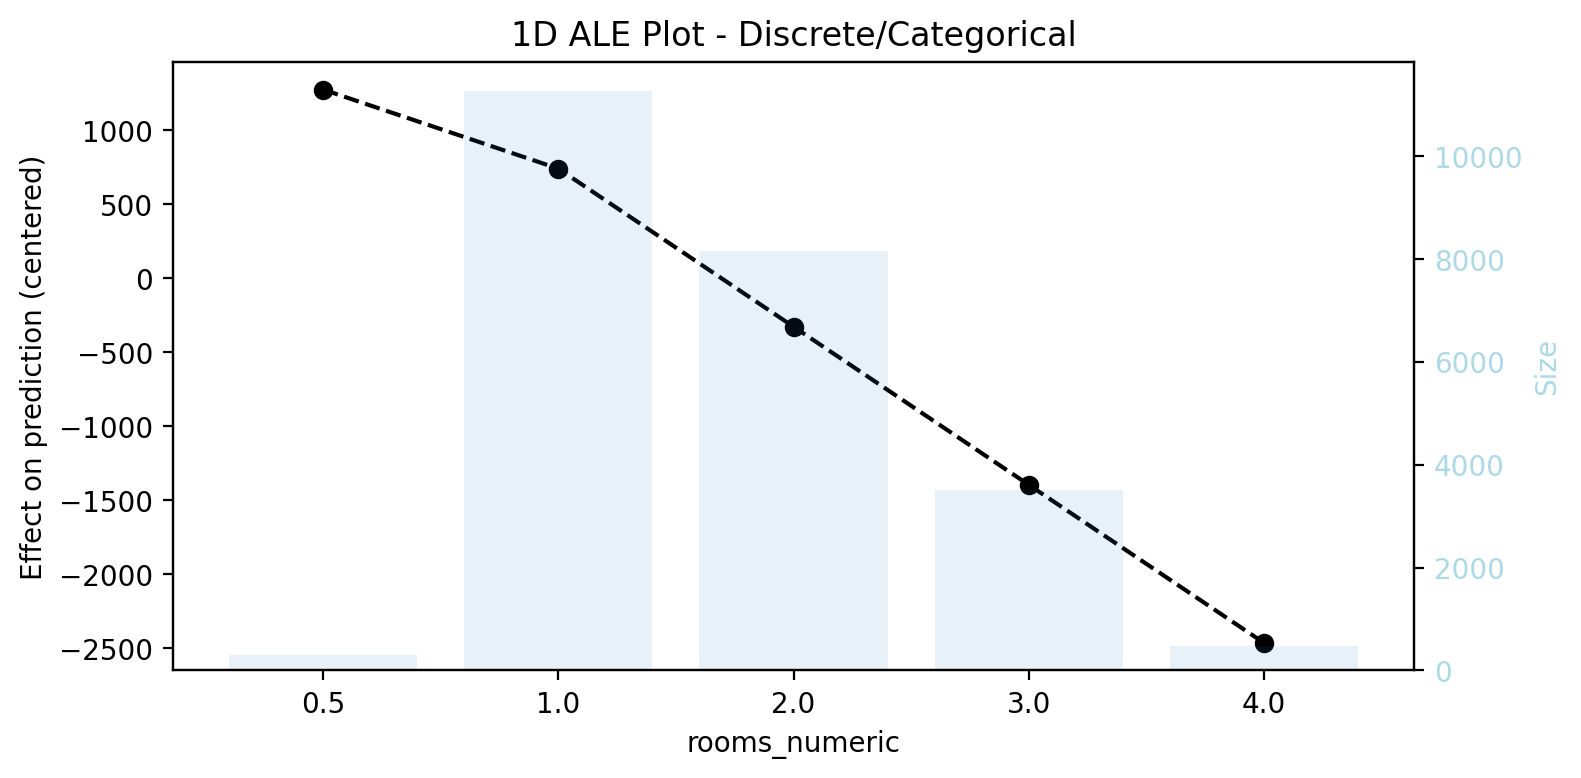

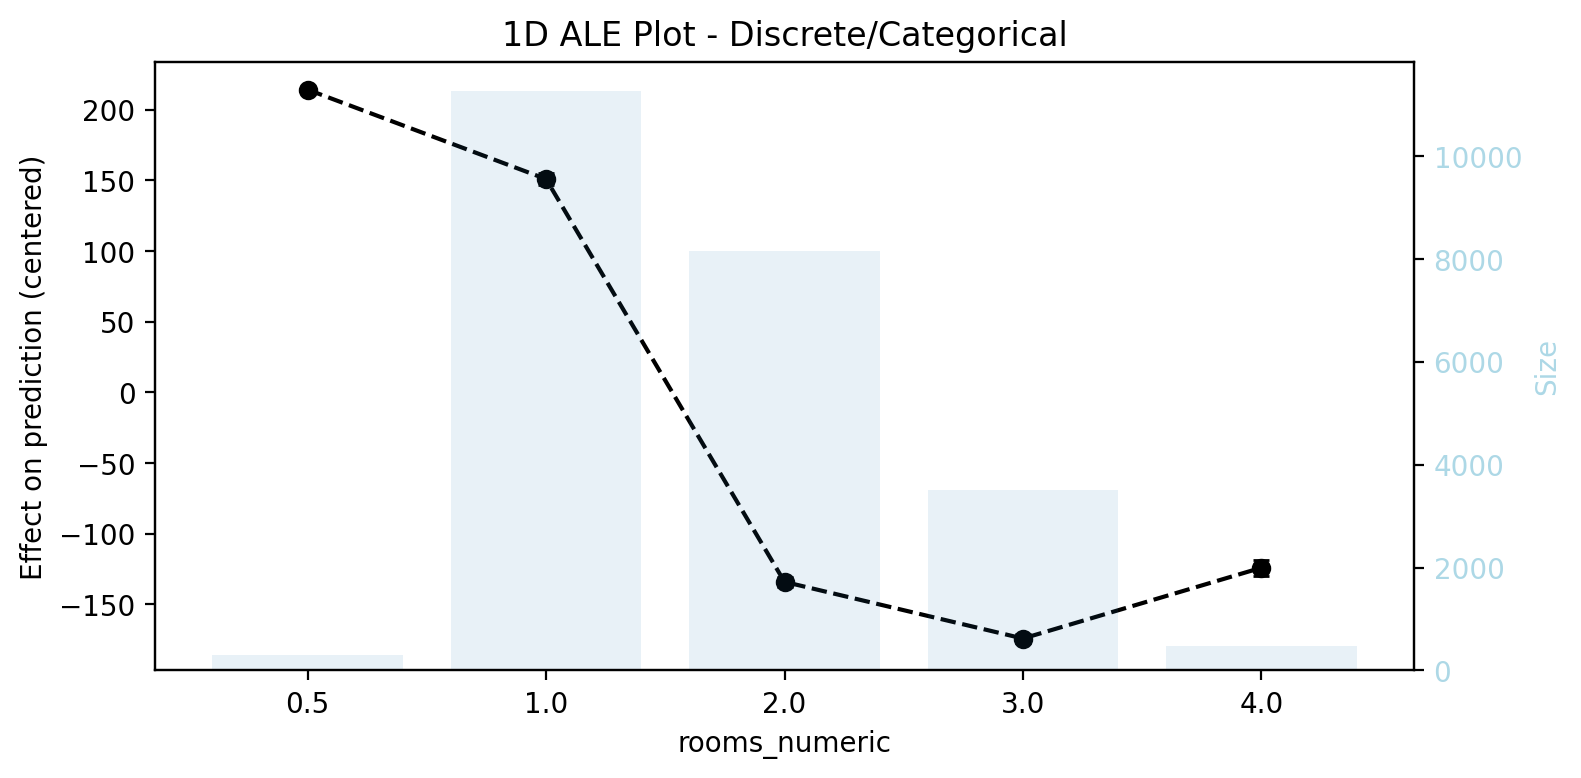

In [ ]:
class ModelWrapper:
    def __init__(self, model, scaler):
        self.model  = model
        self.scaler = scaler

    def predict(self, X_df):
        X_scaled = self.scaler.transform(X_df)
        return self.model.predict(X_scaled)

wrapper_linear   = ModelWrapper(linear_model,   scaler_mm)
wrapper_boosting = ModelWrapper(boosting_model, scaler_mm)

grid_sizes = [5, 10, 20, 50]

print(f"{'grid_size':<12} {'Linear ДИ (ср.)':<20} {'Boosting ДИ (ср.)':<20} {'объектов/бин'}")
print("-" * 65)

for gs in grid_sizes:
    widths = []
    for wrapper in [wrapper_linear, wrapper_boosting]:
        res = ale(
            X=X_train,         
            model=wrapper,       
            feature=[FEATURE],
            grid_size=gs,
            include_CI=True,
            C=0.95
        )
        w = (res['upperCI_95%'] - res['lowerCI_95%']).mean()
        widths.append(f"{w:.4f}")

    objs_per_bin = len(X_train) / gs
    print(f"{gs:<12} {widths[0]:<20} {widths[1]:<20} (~{objs_per_bin:.0f})")

PyALE._ALE_generic:INFO: Discrete feature detected.
PyALE._ALE_generic:INFO: Discrete feature detected.


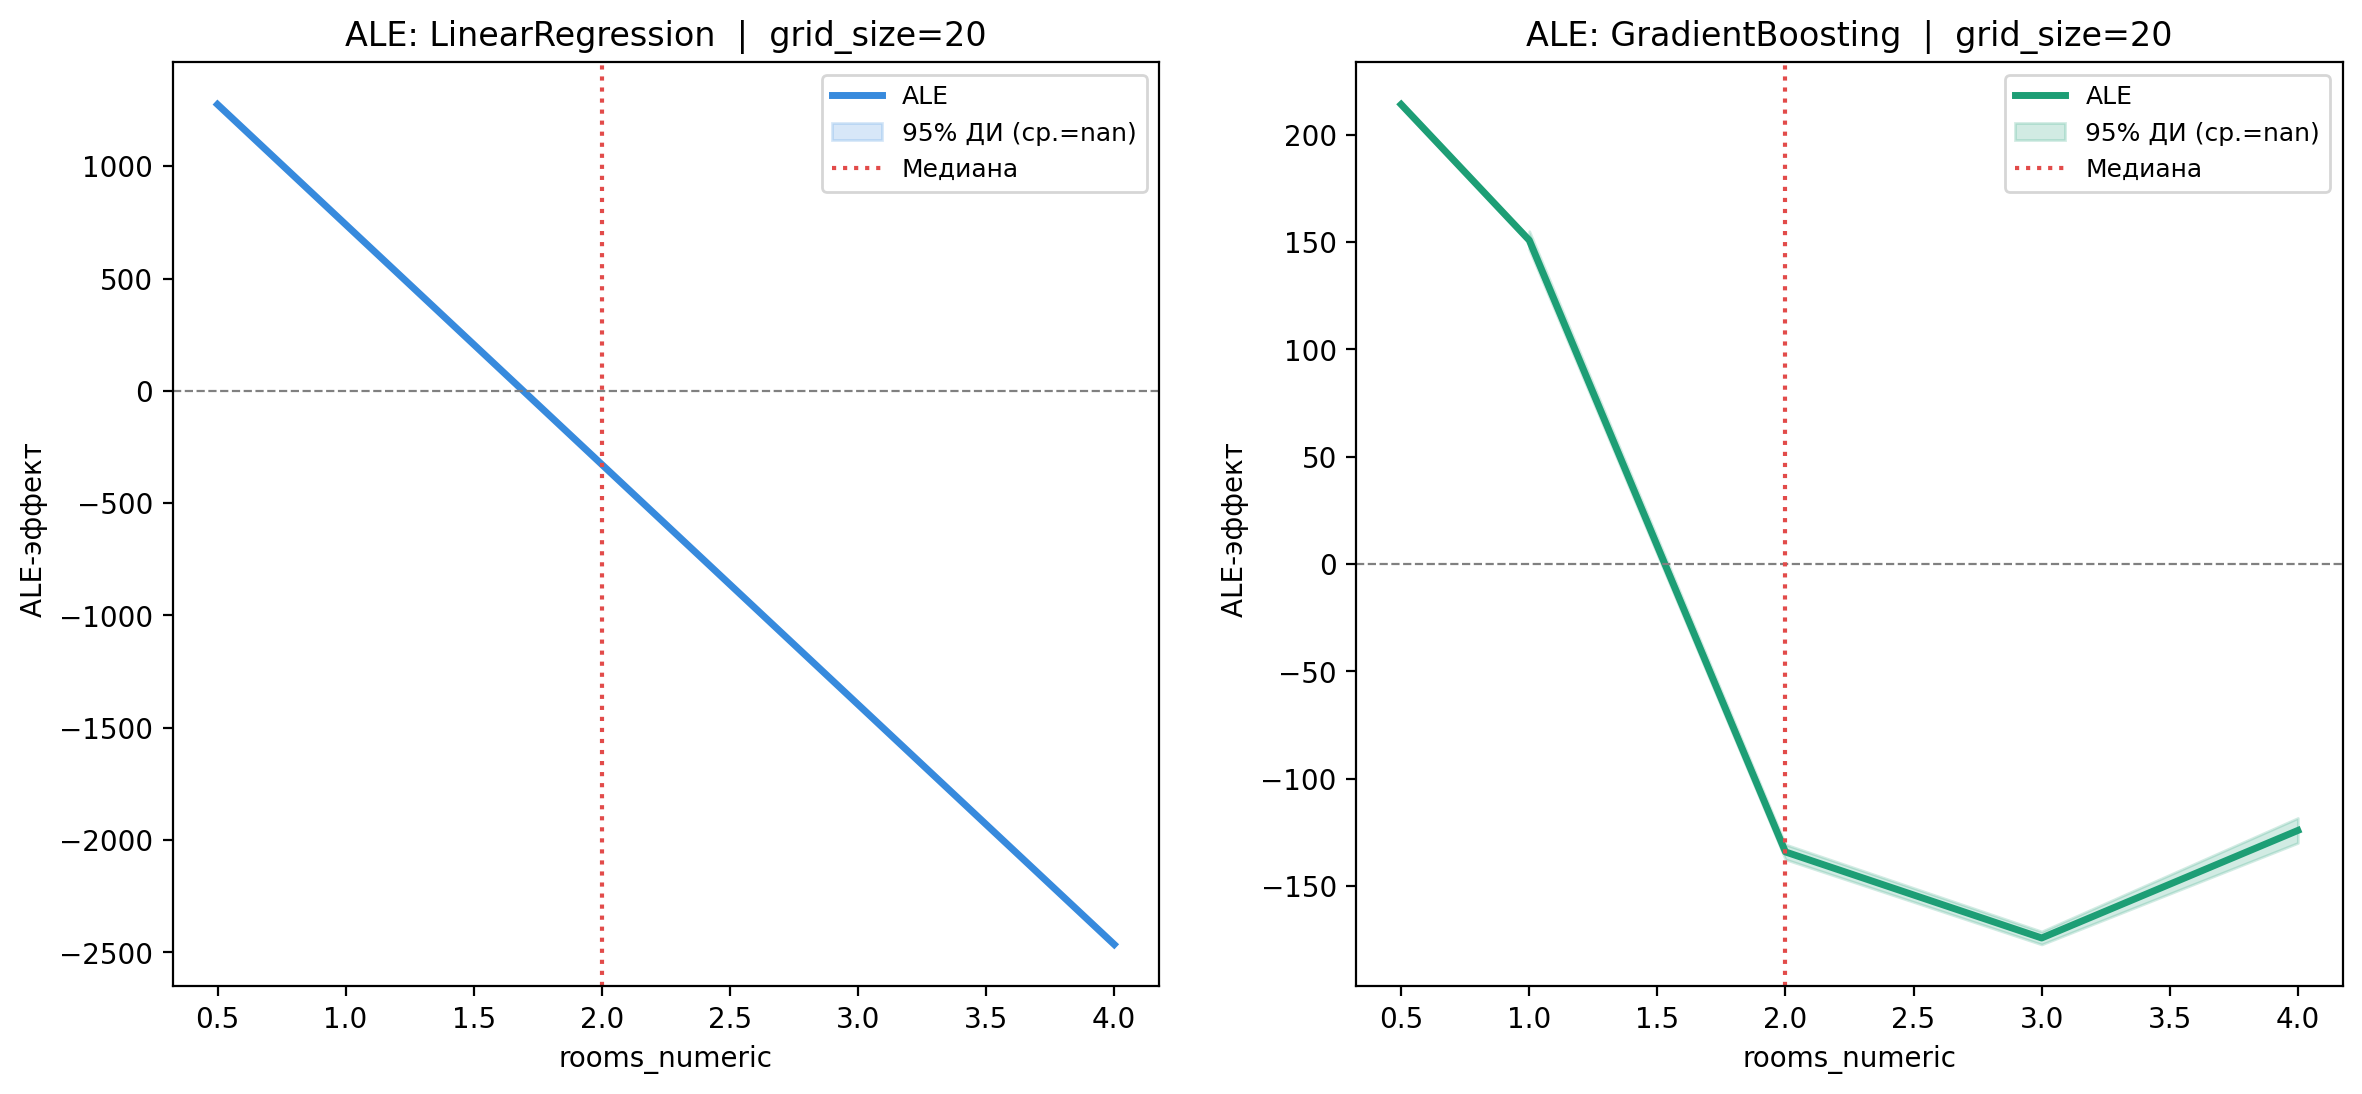

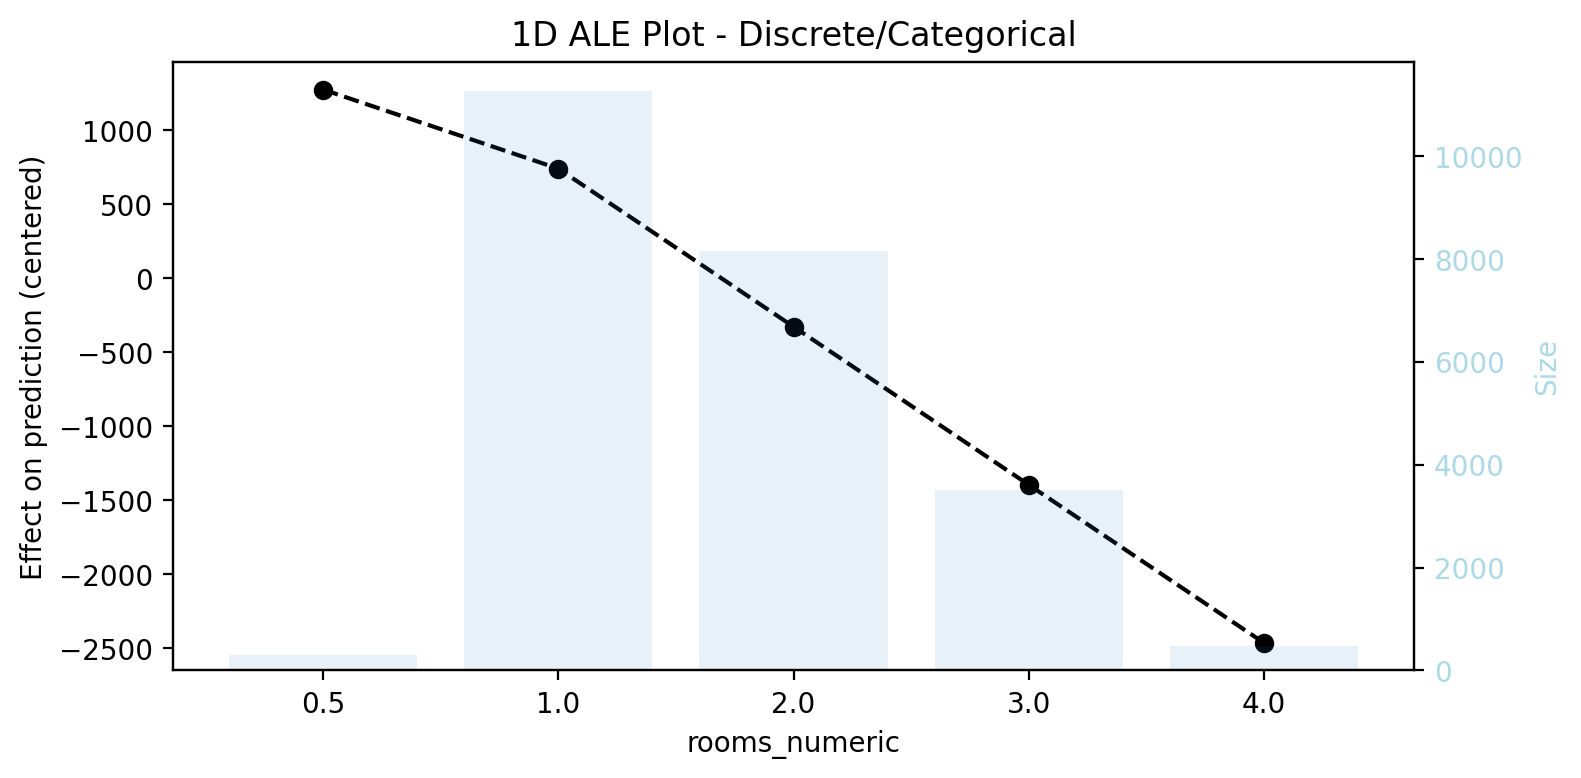

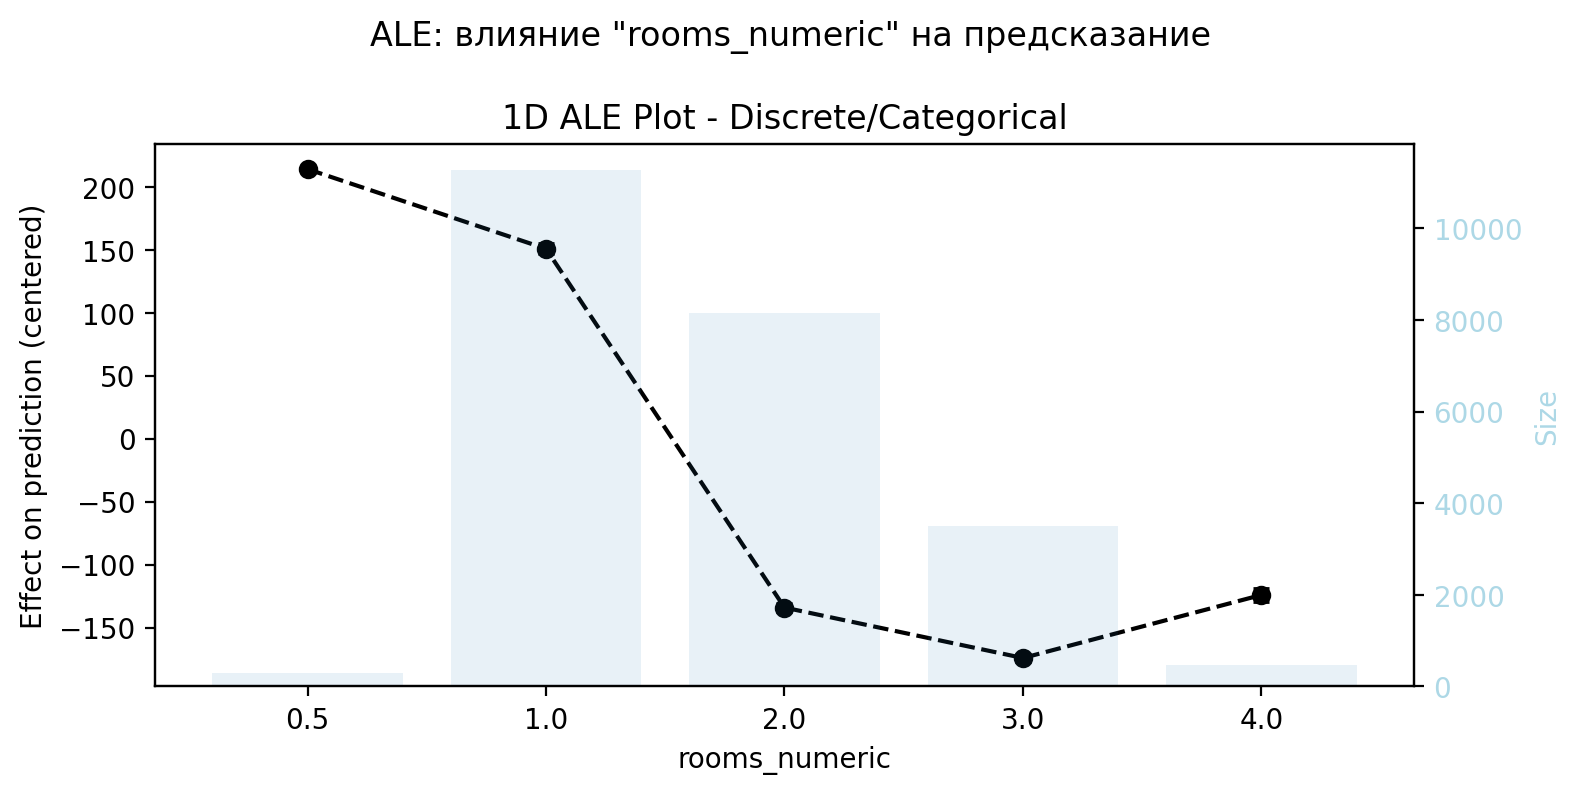

In [12]:
BEST_GRID = 20

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, wrapper, name, color in zip(
    axes,
    [wrapper_linear,   wrapper_boosting],
    ['LinearRegression', 'GradientBoosting'],
    ['#378ADD',          '#1D9E75']
):
    res = ale(
        X=X_train,
        model=wrapper,
        feature=[FEATURE],
        grid_size=BEST_GRID,
        include_CI=True,
        C=0.95
    )

    ale_x = res.index.values
    ale_y = res['eff'].values
    ci_lo = res['lowerCI_95%'].values
    ci_hi = res['upperCI_95%'].values

    ax.plot(ale_x, ale_y, color=color, linewidth=2.5, label='ALE')
    ax.fill_between(ale_x, ci_lo, ci_hi, alpha=0.2, color=color,
                    label=f'95% ДИ (ср.={np.mean(ci_hi-ci_lo):.4f})')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(X_train[FEATURE].median(), color='#E24B4A',
               linestyle=':', linewidth=1.5, label='Медиана')
    ax.set_xlabel(f'{FEATURE}')
    ax.set_ylabel('ALE-эффект ')
    ax.set_title(f'ALE: {name}  |  grid_size={BEST_GRID}')
    ax.legend(fontsize=9)

plt.suptitle(f'ALE: влияние "{FEATURE}" на предсказание')
plt.tight_layout()
plt.show()

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



In [13]:
from sklearn.inspection import permutation_importance

def mape_scorer(estimator, X, y):
    y_pred = estimator.predict(X)
    return -np.mean(np.abs(y - y_pred) / np.abs(y)) * 100
n_repeats_list = [1, 5, 10, 30]
perm_results   = {}

for n_rep in n_repeats_list:
    res = permutation_importance(
        boosting_model, X_test_mm, y_test,
        n_repeats=n_rep, random_state=42, scoring=mape_scorer
    )
    perm_results[n_rep] = res
    top5 = np.argsort(res.importances_mean)[-5:][::-1]
    print(f"\nn_repeats={n_rep}:")
    for i in top5:
        print(f"  {numeric_columns[i]:<40} "
              f"mean={res.importances_mean[i]:.4f}  "
              f"std={res.importances_std[i]:.4f}")


n_repeats=1:
  class_cat                                mean=14.5003  std=0.0000
  location_logs_count_mean                 mean=4.3892  std=0.0000
  location_public_transport_stop_position_cnt mean=2.1987  std=0.0000
  location_town_w_mean_distance            mean=1.9568  std=0.0000
  location_leisure_w_mean_distance         mean=1.5582  std=0.0000

n_repeats=5:
  class_cat                                mean=14.5703  std=0.2426
  location_logs_count_mean                 mean=4.5129  std=0.1215
  location_public_transport_stop_position_cnt mean=2.1803  std=0.0479
  location_town_w_mean_distance            mean=1.9551  std=0.0403
  location_leisure_w_mean_distance         mean=1.5843  std=0.0437

n_repeats=10:
  class_cat                                mean=14.6267  std=0.2379
  location_logs_count_mean                 mean=4.5164  std=0.0930
  location_public_transport_stop_position_cnt mean=2.1688  std=0.0371
  location_town_w_mean_distance            mean=1.9490  std=0.0404
  locat

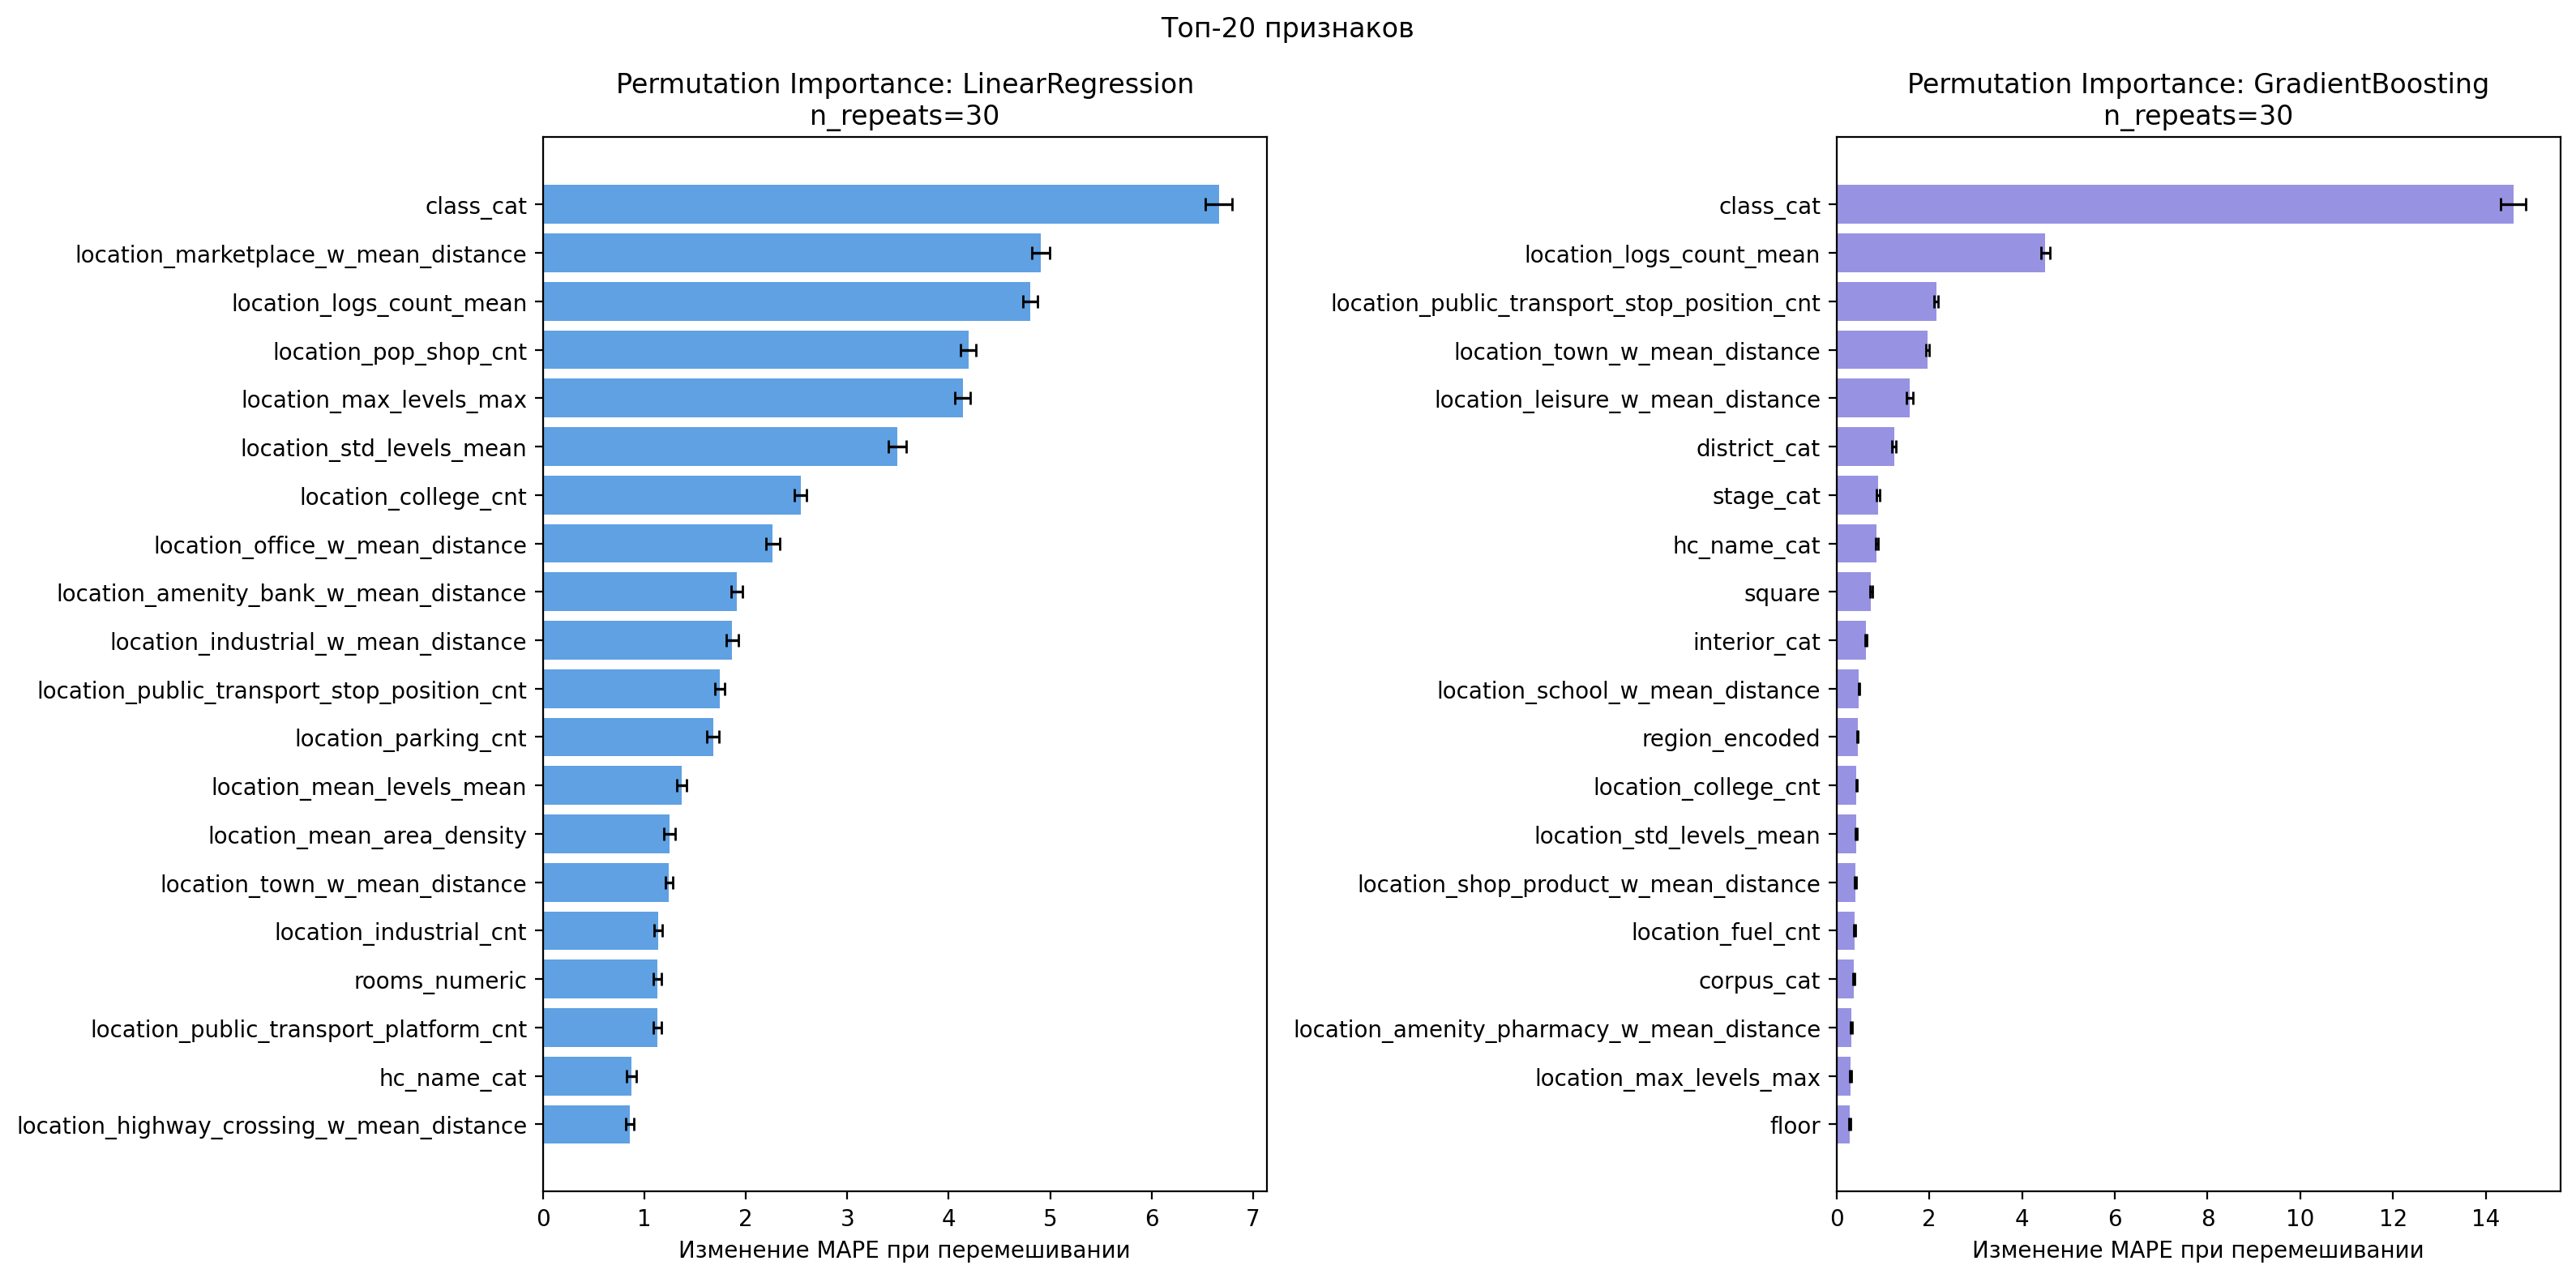

In [14]:
perm_linear   = permutation_importance(
    linear_model, X_test_mm, y_test,
    n_repeats=30, random_state=42, scoring=mape_scorer
)
perm_boosting = permutation_importance(
    boosting_model, X_test_mm, y_test,
    n_repeats=30, random_state=42, scoring=mape_scorer
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, res, name, color in zip(
    axes,
    [perm_linear,  perm_boosting],
    ['LinearRegression', 'GradientBoosting'],
    ['#378ADD',          '#7F77DD']
):
    top20 = np.argsort(res.importances_mean)[-20:]
    names = [numeric_columns[i] for i in top20]
    means = res.importances_mean[top20]
    stds  = res.importances_std[top20]
    ax.barh(names, means, xerr=stds, color=color, alpha=0.8,
            error_kw={'linewidth': 1.2, 'capsize': 3, 'color': 'gray'})
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_title(f'Permutation Importance: {name}\nn_repeats=30')
    ax.set_xlabel('Изменение MAPE при перемешивании')

plt.suptitle('Топ-20 признаков')
plt.tight_layout()
plt.show()

## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

In [15]:

baseline = mape(y_test, boosting_model.predict(X_test_mm))
medians  = np.median(X_train_mm, axis=0)
print(f"Базовый MAPE: {baseline:.4f}%")

top30_idx   = np.argsort(perm_boosting.importances_mean)[-30:][::-1]
top30_names = [numeric_columns[i] for i in top30_idx]

beta_values      = [0.0, 0.25, 0.5, 0.75, 1.0]
shift_importance = {}

for beta in beta_values:
    diffs = []
    for feat_name in top30_names:
        fi        = numeric_columns.index(feat_name)
        X_mod     = X_test_mm.copy()
        X_mod[:, fi] = (1 - beta) * X_test_mm[:, fi] + beta * medians[fi]
        delta = mape(y_test, boosting_model.predict(X_mod)) - baseline
        diffs.append(delta)
    shift_importance[beta] = pd.Series(diffs, index=top30_names)
    top = shift_importance[beta].idxmax()
    print(f"β={beta:.2f}  топ: {top} (ΔMAPE={shift_importance[beta].max():.4f}%)")

Базовый MAPE: 4.0433%
β=0.00  топ: class_cat (ΔMAPE=0.0000%)
β=0.25  топ: location_town_w_mean_distance (ΔMAPE=0.4492%)
β=0.50  топ: location_leisure_w_mean_distance (ΔMAPE=1.5210%)
β=0.75  топ: class_cat (ΔMAPE=4.8977%)
β=1.00  топ: class_cat (ΔMAPE=4.8977%)


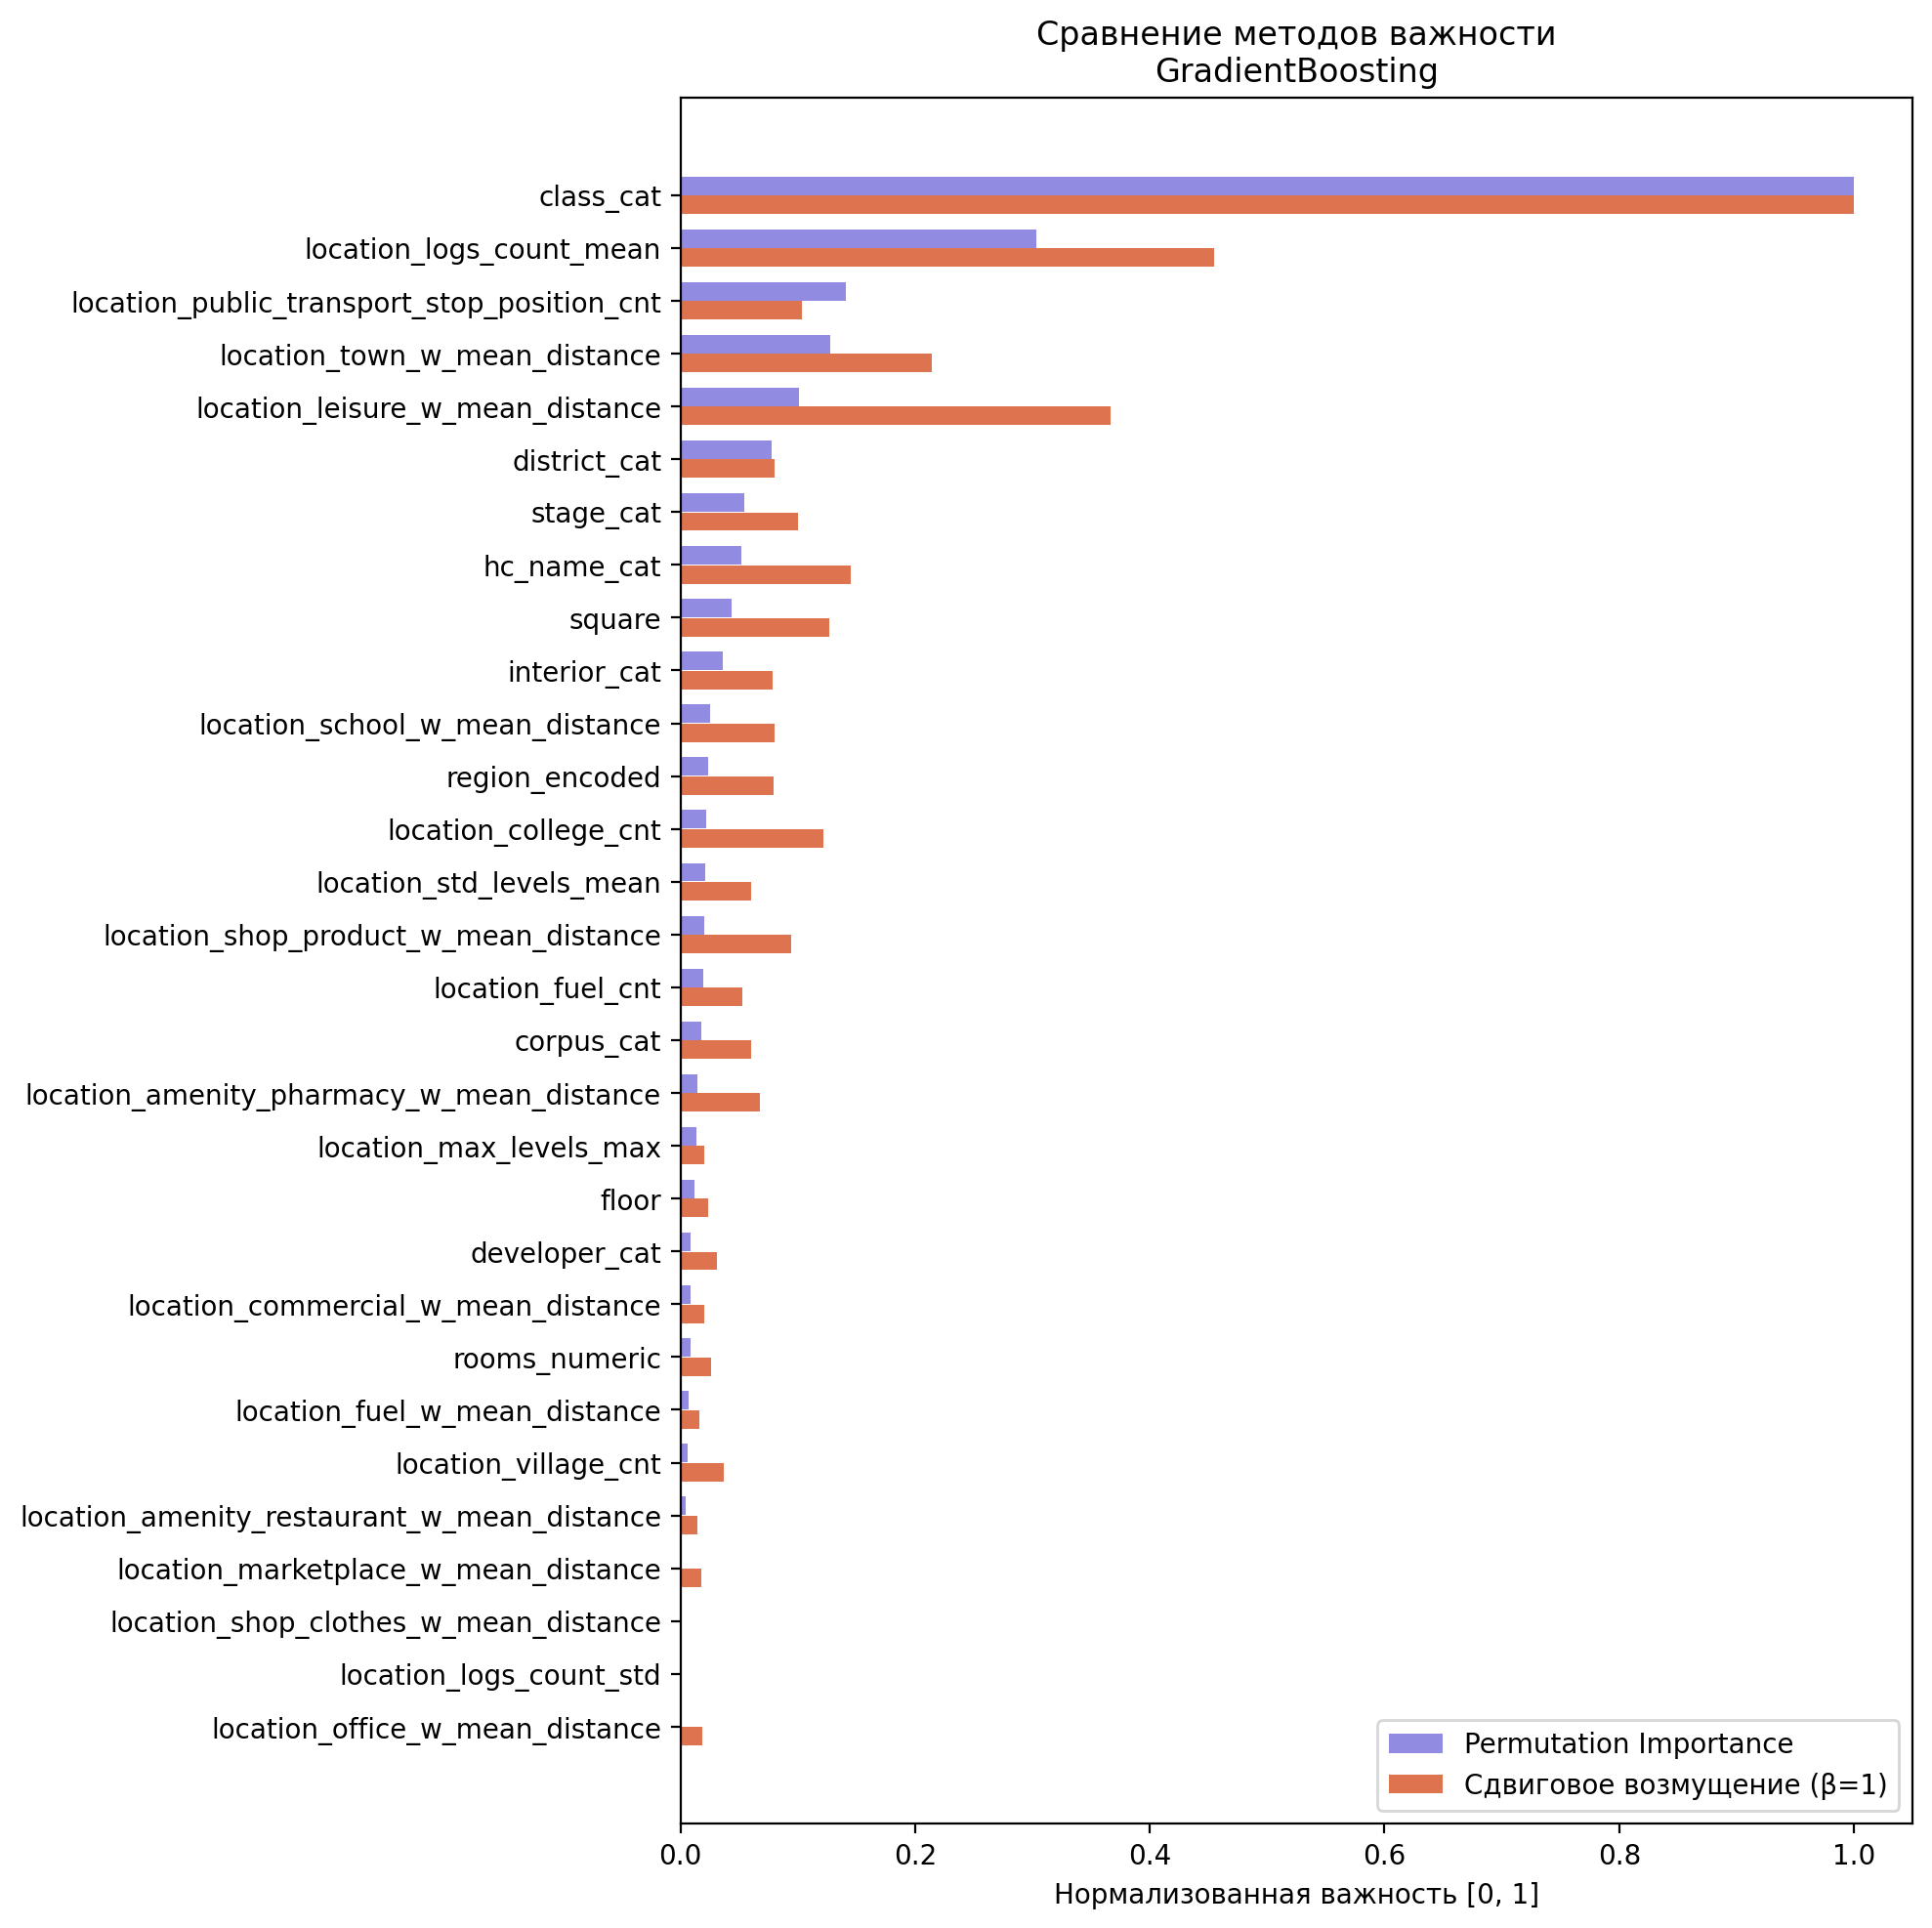

In [16]:

perm_s  = pd.Series(perm_boosting.importances_mean[top30_idx], index=top30_names)
shift_s = shift_importance[1.0]

def norm01(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

perm_n  = norm01(perm_s)
shift_n = norm01(shift_s)
order   = perm_n.sort_values().index

fig, ax = plt.subplots(figsize=(10, 10))
y_pos   = np.arange(len(order))
ax.barh(y_pos + 0.18, perm_n[order],  height=0.35, color='#7F77DD',
        alpha=0.85, label='Permutation Importance')
ax.barh(y_pos - 0.18, shift_n[order], height=0.35, color='#D85A30',
        alpha=0.85, label='Сдвиговое возмущение (β=1)')
ax.set_yticks(y_pos)
ax.set_yticklabels(order)
ax.set_xlabel('Нормализованная важность [0, 1]')
ax.set_title('Сравнение методов важности\nGradientBoosting')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 



In [17]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_mm,
    feature_names=numeric_columns,
    mode='regression',
    random_state=42
)

y_test_arr = y_test.values
idx_cheap     = int(np.argmin(y_test_arr))
idx_median    = int(np.argmin(np.abs(y_test_arr - np.median(y_test_arr))))
idx_expensive = int(np.argmax(y_test_arr))

objects = [
    (idx_cheap,     'Дешeвая'),
    (idx_median,    'Медианная'),
    (idx_expensive, 'Дорогая'),
]

print("Объекты для объяснения:")
for idx, label in objects:
    print(f"  {label}: {y_test_arr[idx]:.0f} р за м2")

Объекты для объяснения:
  Дешeвая: 15859 р за м2
  Медианная: 22157 р за м2
  Дорогая: 63067 р за м2


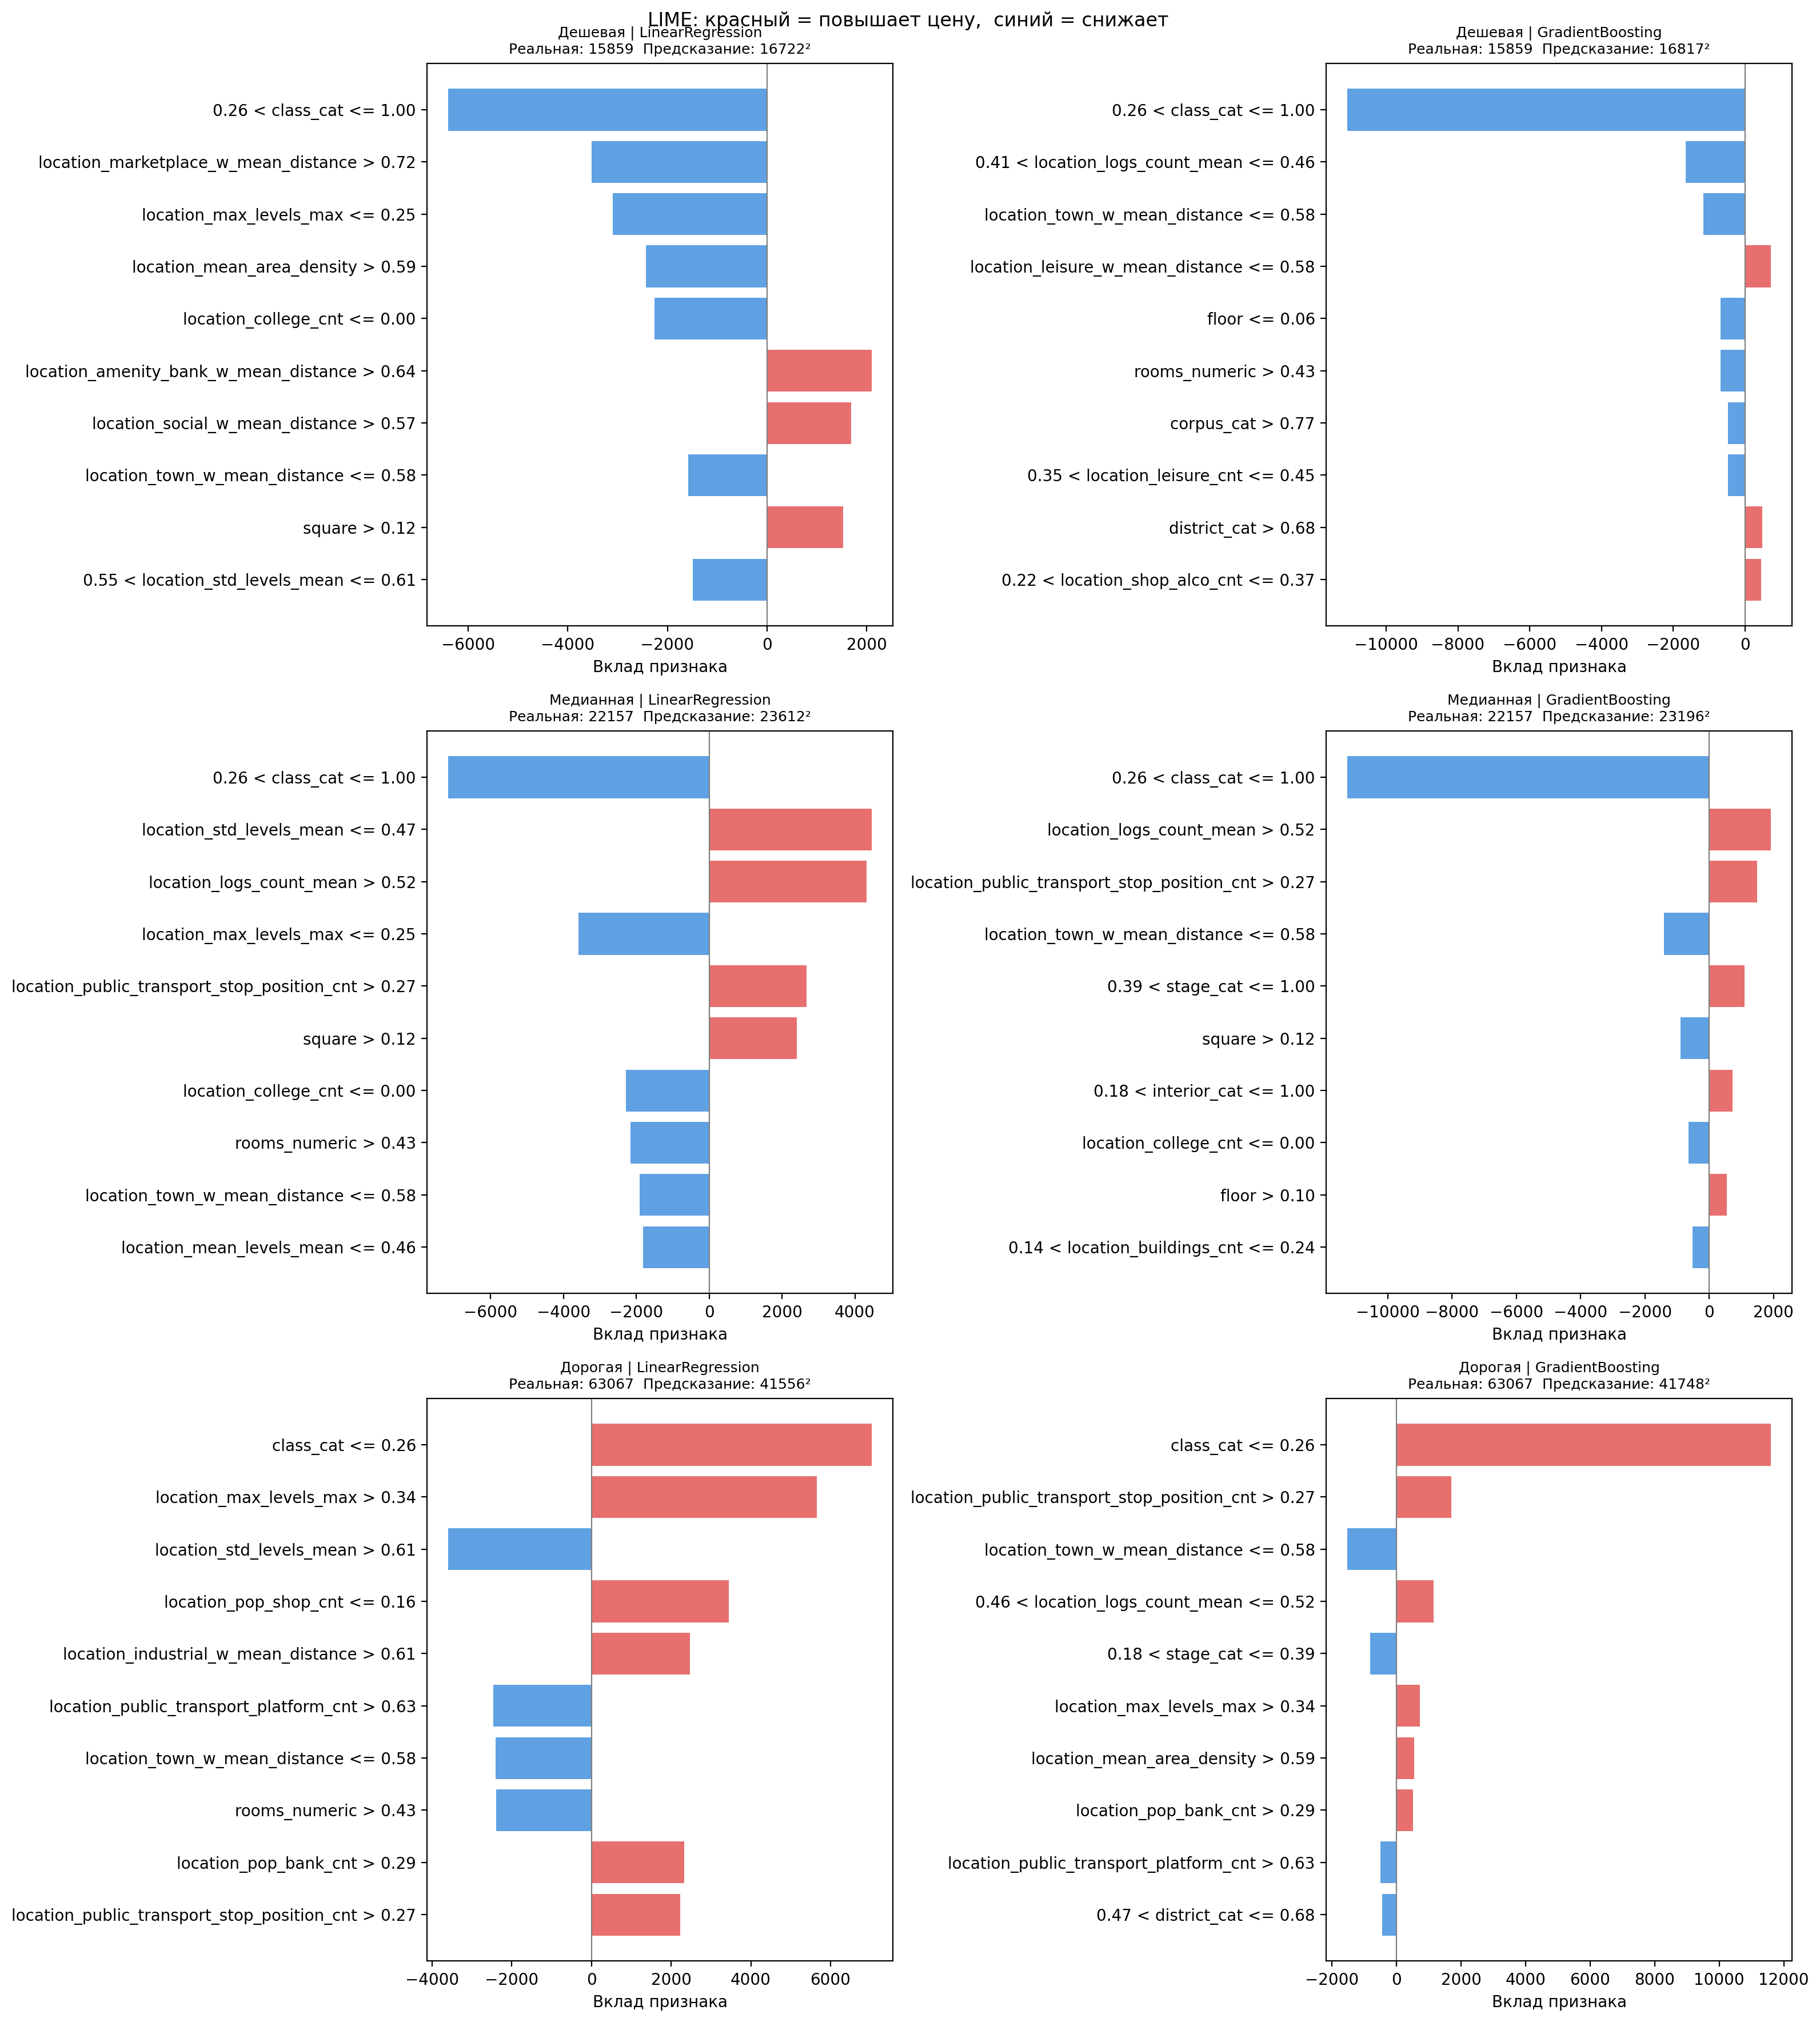

In [18]:

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for row, (obj_idx, obj_label) in enumerate(objects):
    obj_row    = X_test_mm[obj_idx]
    real_price = y_test_arr[obj_idx]

    for col, (model, m_name) in enumerate([
        (linear_model,   'LinearRegression'),
        (boosting_model, 'GradientBoosting'),
    ]):
        ax  = axes[row, col]
        exp = explainer_lime.explain_instance(
            data_row=obj_row,
            predict_fn=model.predict,
            num_features=10,
            num_samples=1000
        )
        items  = exp.as_list()
        labels = [x[0] for x in items]
        vals   = [x[1] for x in items]
        colors = ['#E24B4A' if v > 0 else '#378ADD' for v in vals]

        ax.barh(labels[::-1], vals[::-1], color=colors[::-1], alpha=0.8)
        ax.axvline(0, color='gray', linewidth=0.8)
        pred = model.predict(obj_row.reshape(1, -1))[0]
        ax.set_title(f'{obj_label} | {m_name}\n'
                     f'Реальная: {real_price:.0f}  Предсказание: {pred:.0f}²',
                     fontsize=9)
        ax.set_xlabel('Вклад признака')

plt.suptitle('LIME: красный = повышает цену,  синий = снижает', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:

obj_row = X_test_mm[idx_median]

exp_ref = explainer_lime.explain_instance(
    obj_row,
    boosting_model.predict,
    num_features=len(numeric_columns),
    num_samples=1000
)
coef_ref = dict(exp_ref.as_list())
tracked  = max(coef_ref, key=lambda k: abs(coef_ref[k]))
print(f"Отслеживаем: '{tracked}'  (коэф={coef_ref[tracked]:.4f})")

sample_sizes = [50, 200, 500, 1000, 3000]
all_coefs    = {ns: [] for ns in sample_sizes}

for ns in sample_sizes:
    for run in range(7):
        exp_temp = lime.lime_tabular.LimeTabularExplainer(
            training_data=X_train_mm,
            feature_names=numeric_columns,
            mode='regression',
            random_state=run     
        )
        exp = exp_temp.explain_instance(
            obj_row,
            boosting_model.predict,
            num_features=len(numeric_columns),
            num_samples=ns
        )
        cd = dict(exp.as_list())
        if tracked in cd:
            all_coefs[ns].append(cd[tracked])

    print(f"num_samples={ns:>5}: "
          f"mean={np.mean(all_coefs[ns]):>8.4f}  "
          f"std={np.std(all_coefs[ns]):>7.4f}")

Отслеживаем: '0.26 < class_cat <= 1.00'  (коэф=-11251.5184)
num_samples=   50: mean=-5659.0065  std=987.0129
num_samples=  200: mean=-10536.7266  std=360.2674
num_samples=  500: mean=-11186.6549  std=268.6493
num_samples= 1000: mean=-11183.4870  std=353.3403
num_samples= 3000: mean=-11477.6182  std=88.6794


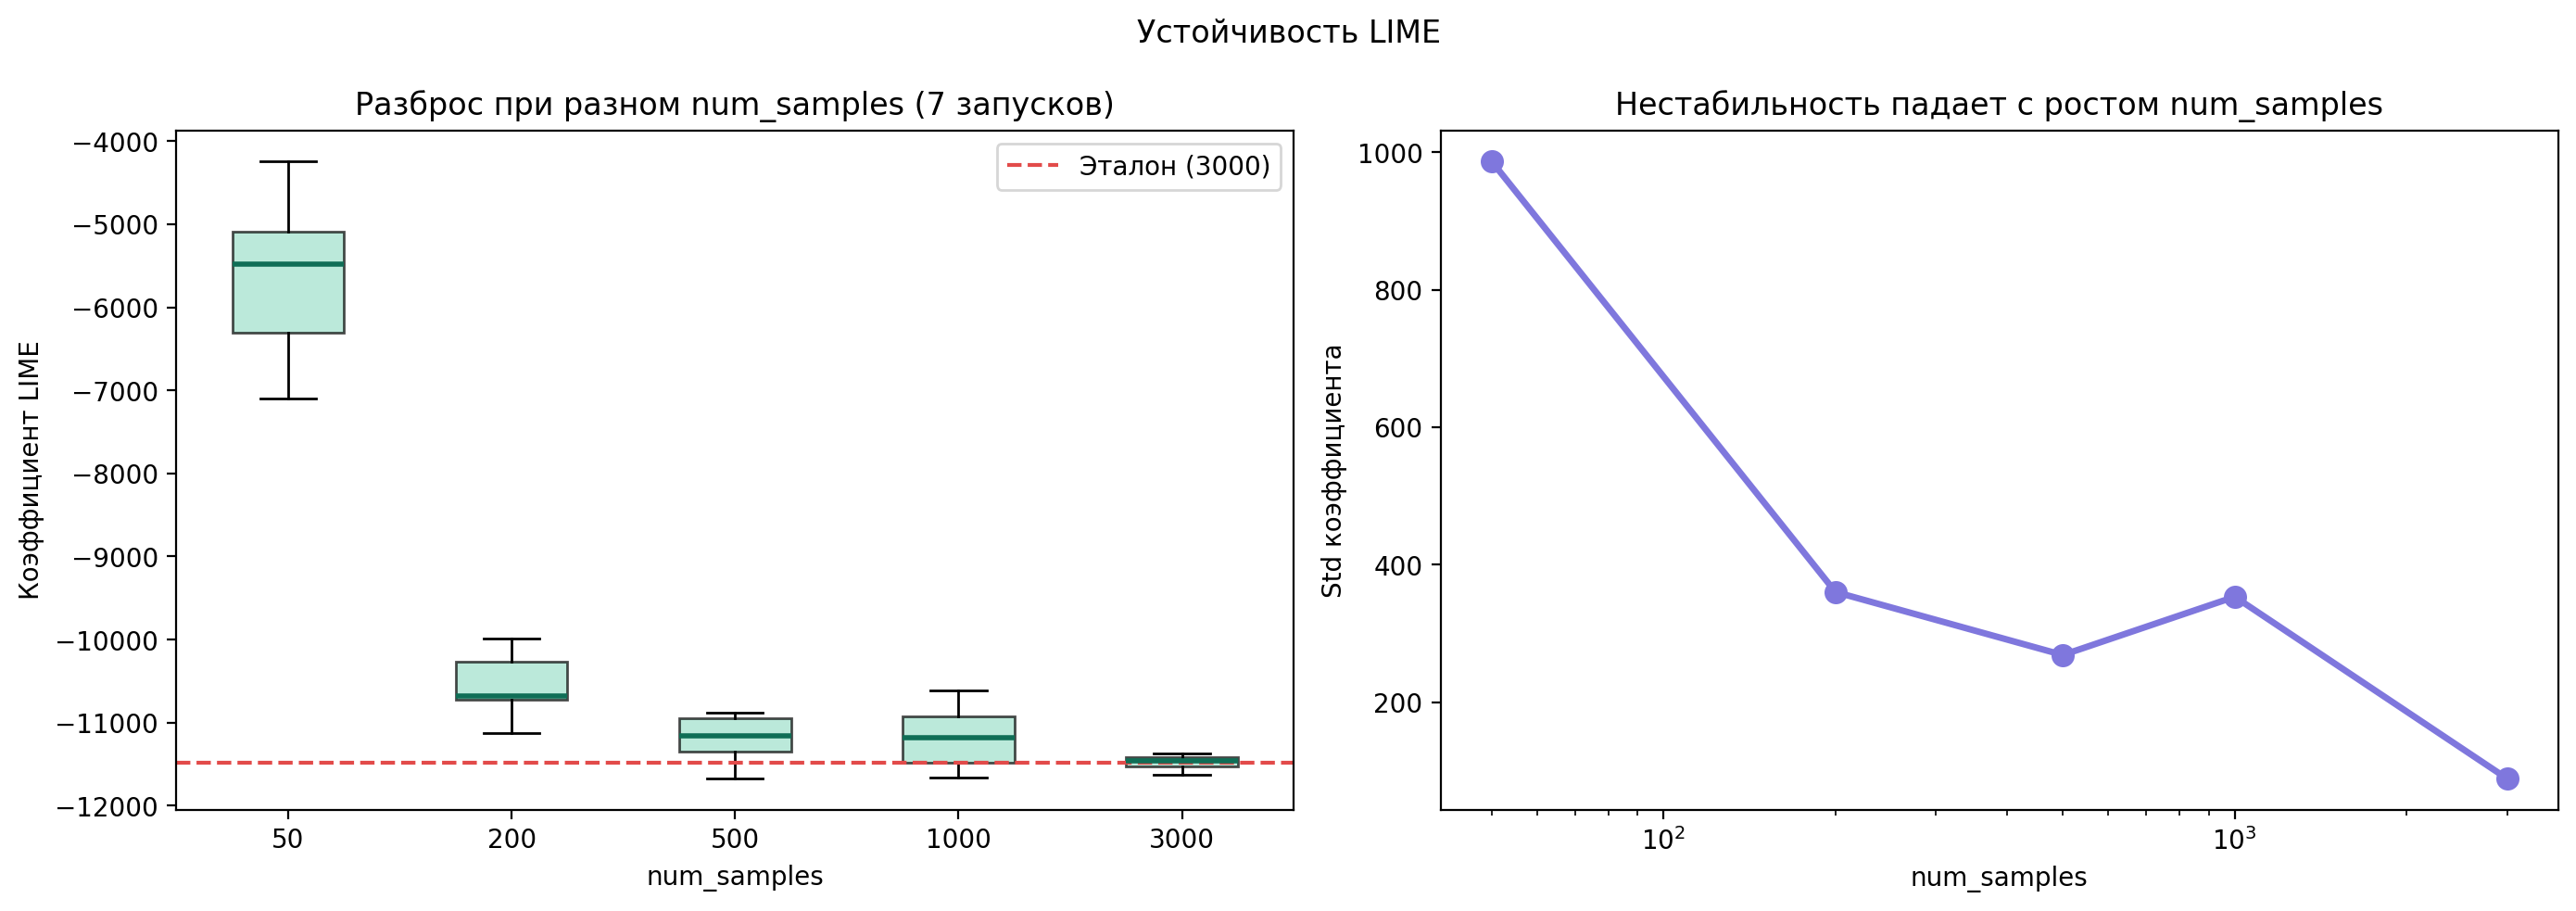

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(
    [all_coefs[ns] for ns in sample_sizes],
    labels=[str(ns) for ns in sample_sizes],
    patch_artist=True,
    boxprops=dict(facecolor='#9FE1CB', alpha=0.7),
    medianprops=dict(color='#0F6E56', linewidth=2)
)
axes[0].axhline(np.mean(all_coefs[3000]), color='#E24B4A',
                linestyle='--', linewidth=1.5, label='Эталон (3000)')
axes[0].set_xlabel('num_samples')
axes[0].set_ylabel(f'Коэффициент LIME')
axes[0].set_title('Разброс при разном num_samples (7 запусков)')
axes[0].legend()

# Std
stds = [np.std(all_coefs[ns]) for ns in sample_sizes]
axes[1].plot(sample_sizes, stds, color='#7F77DD', linewidth=2.5,
             marker='o', markersize=8)
axes[1].set_xlabel('num_samples')
axes[1].set_ylabel('Std коэффициента')
axes[1].set_title('Нестабильность падает с ростом num_samples')
axes[1].set_xscale('log')

plt.suptitle('Устойчивость LIME')
plt.tight_layout()
plt.show()

## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 


In [22]:
shap_explainer_b = shap.TreeExplainer(boosting_model)
shap_explainer_l = shap.LinearExplainer(linear_model, X_train_mm)

base_b = shap_explainer_b.expected_value
base_l = shap_explainer_l.expected_value

# Если expected_value возвращает массив — берём скаляр
if hasattr(base_b, '__len__'):
    base_b = float(base_b[0])
if hasattr(base_l, '__len__'):
    base_l = float(base_l[0])

print(f"Base value (GradientBoosting):  {base_b:.2f}")
print(f"Base value (LinearRegression):  {base_l:.2f}")

Base value (GradientBoosting):  23940.30
Base value (LinearRegression):  25021.15


In [23]:
# Подвыборка теста
np.random.seed(1)
sample_idx = np.random.choice(len(X_test_mm), size=300, replace=False)
X_shap     = X_test_mm[sample_idx]
y_shap     = y_test.values[sample_idx]

# Вычисляем SHAP-значения
shap_vals_b_raw = shap_explainer_b.shap_values(X_shap)
shap_vals_l_raw = shap_explainer_l.shap_values(X_shap)

# Если список — берём первый элемент
shap_vals_b = shap_vals_b_raw[0] if isinstance(shap_vals_b_raw, list) else shap_vals_b_raw
shap_vals_l = shap_vals_l_raw[0] if isinstance(shap_vals_l_raw, list) else shap_vals_l_raw

print(f"shap_vals_b shape: {shap_vals_b.shape}")
print(f"shap_vals_l shape: {shap_vals_l.shape}")

# Проверка аддитивности
obj   = 0
total = base_b + shap_vals_b[obj].sum()
pred  = float(boosting_model.predict(X_shap[obj].reshape(1, -1))[0])
print(f"\nПроверка: base + sum(SHAP) = {total:.2f},  model.predict = {pred:.2f}")
print(f"Разница: {abs(total - pred):.6f}  ← должна быть ≈ 0")

shap_vals_b shape: (300, 76)
shap_vals_l shape: (300, 76)

Проверка: base + sum(SHAP) = 19336.51,  model.predict = 19336.51
Разница: 0.000000  ← должна быть ≈ 0


Реальная цена:       17766
Предсказание модели: 19337

--- GradientBoosting ---


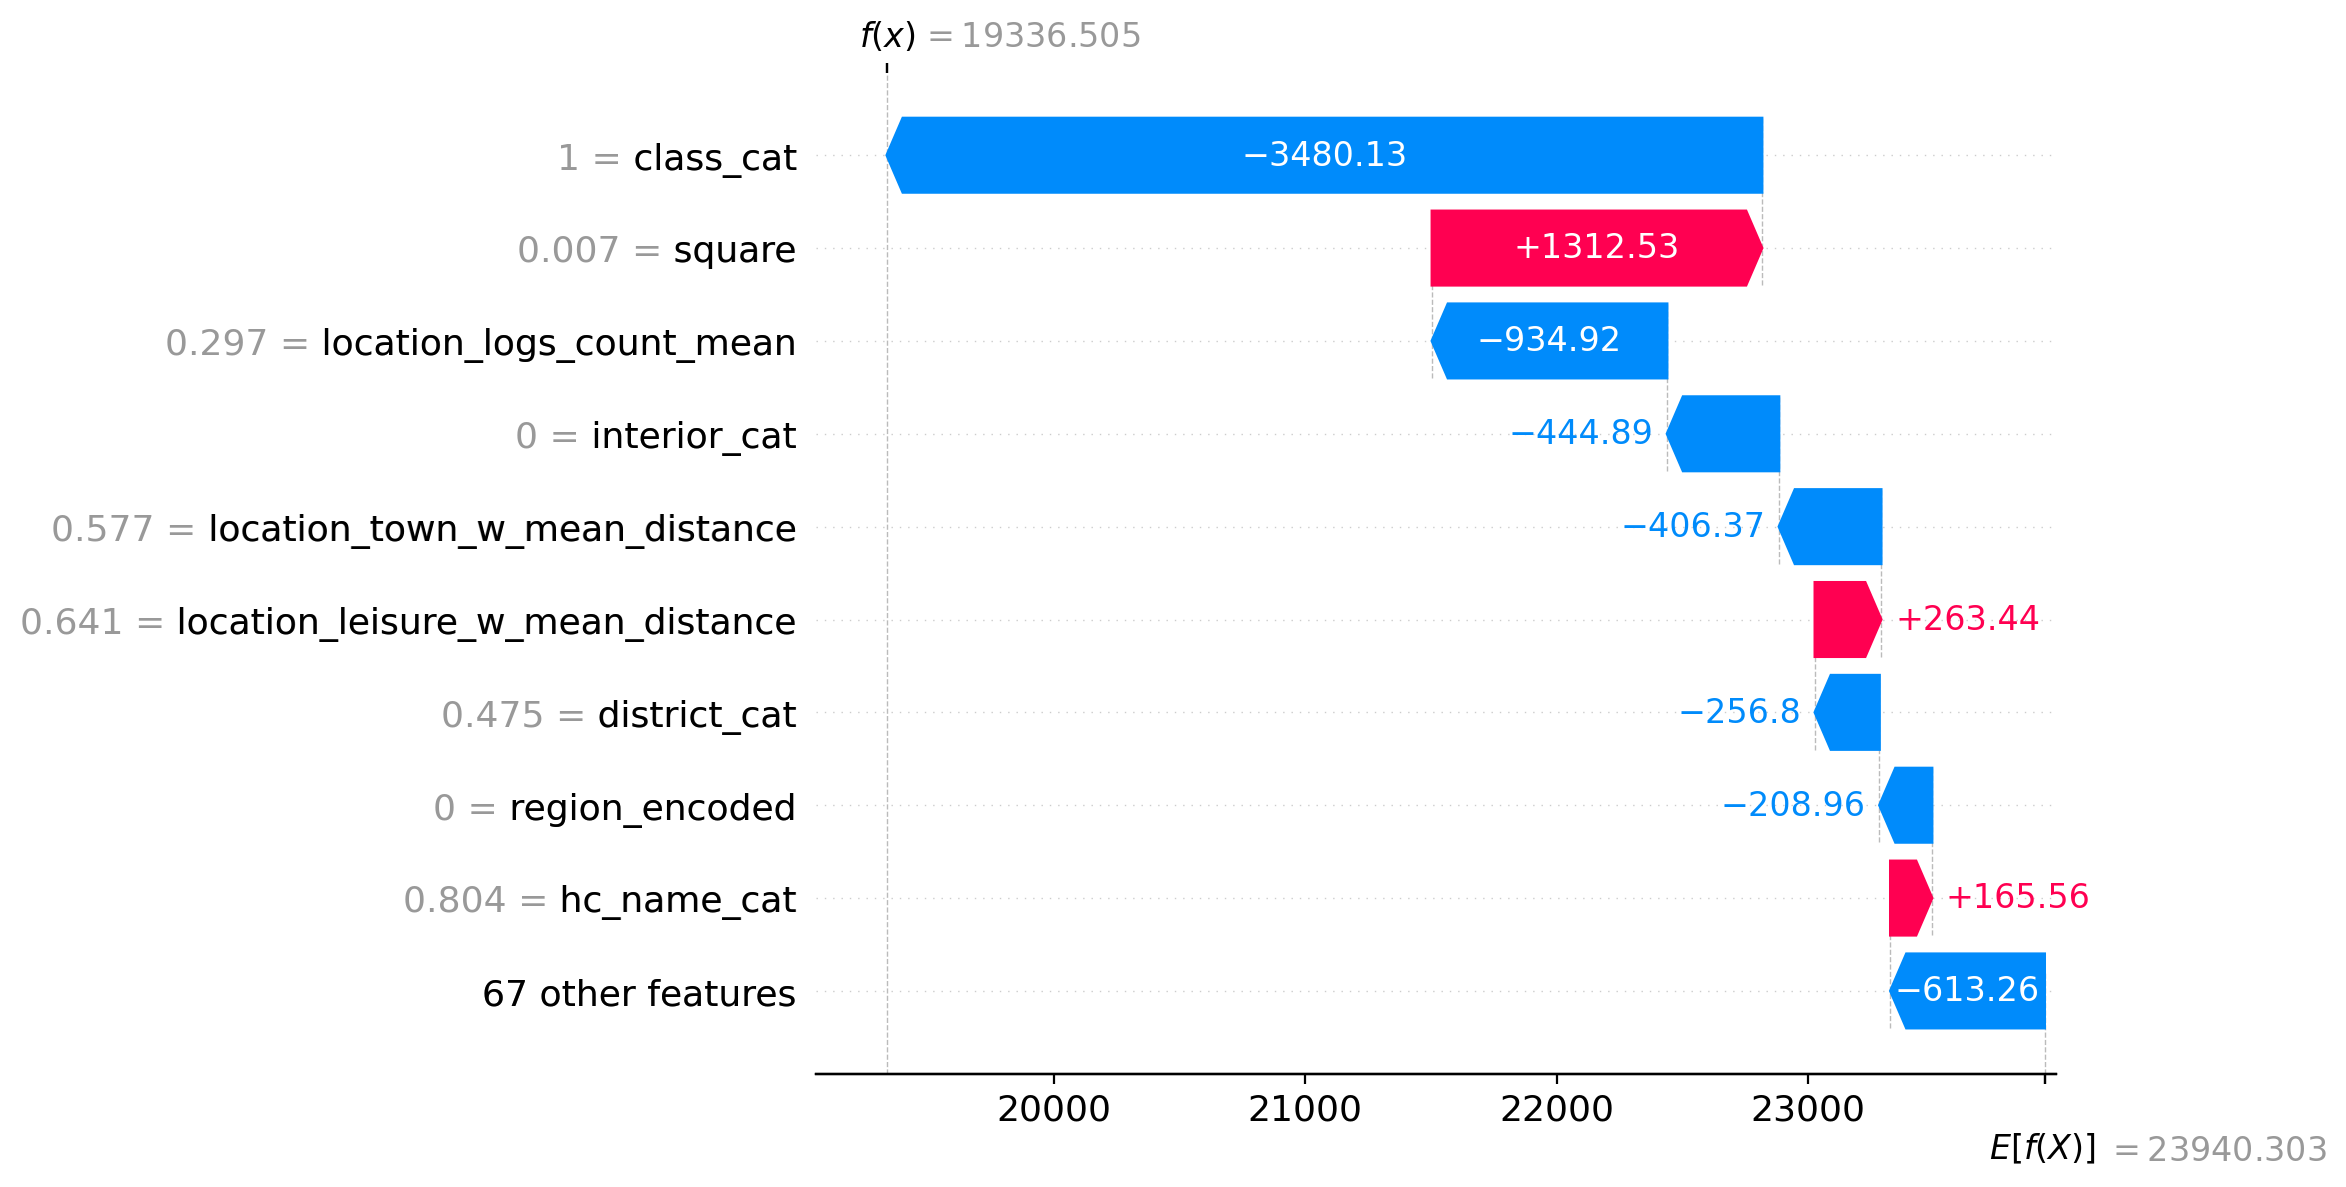


--- LinearRegression ---


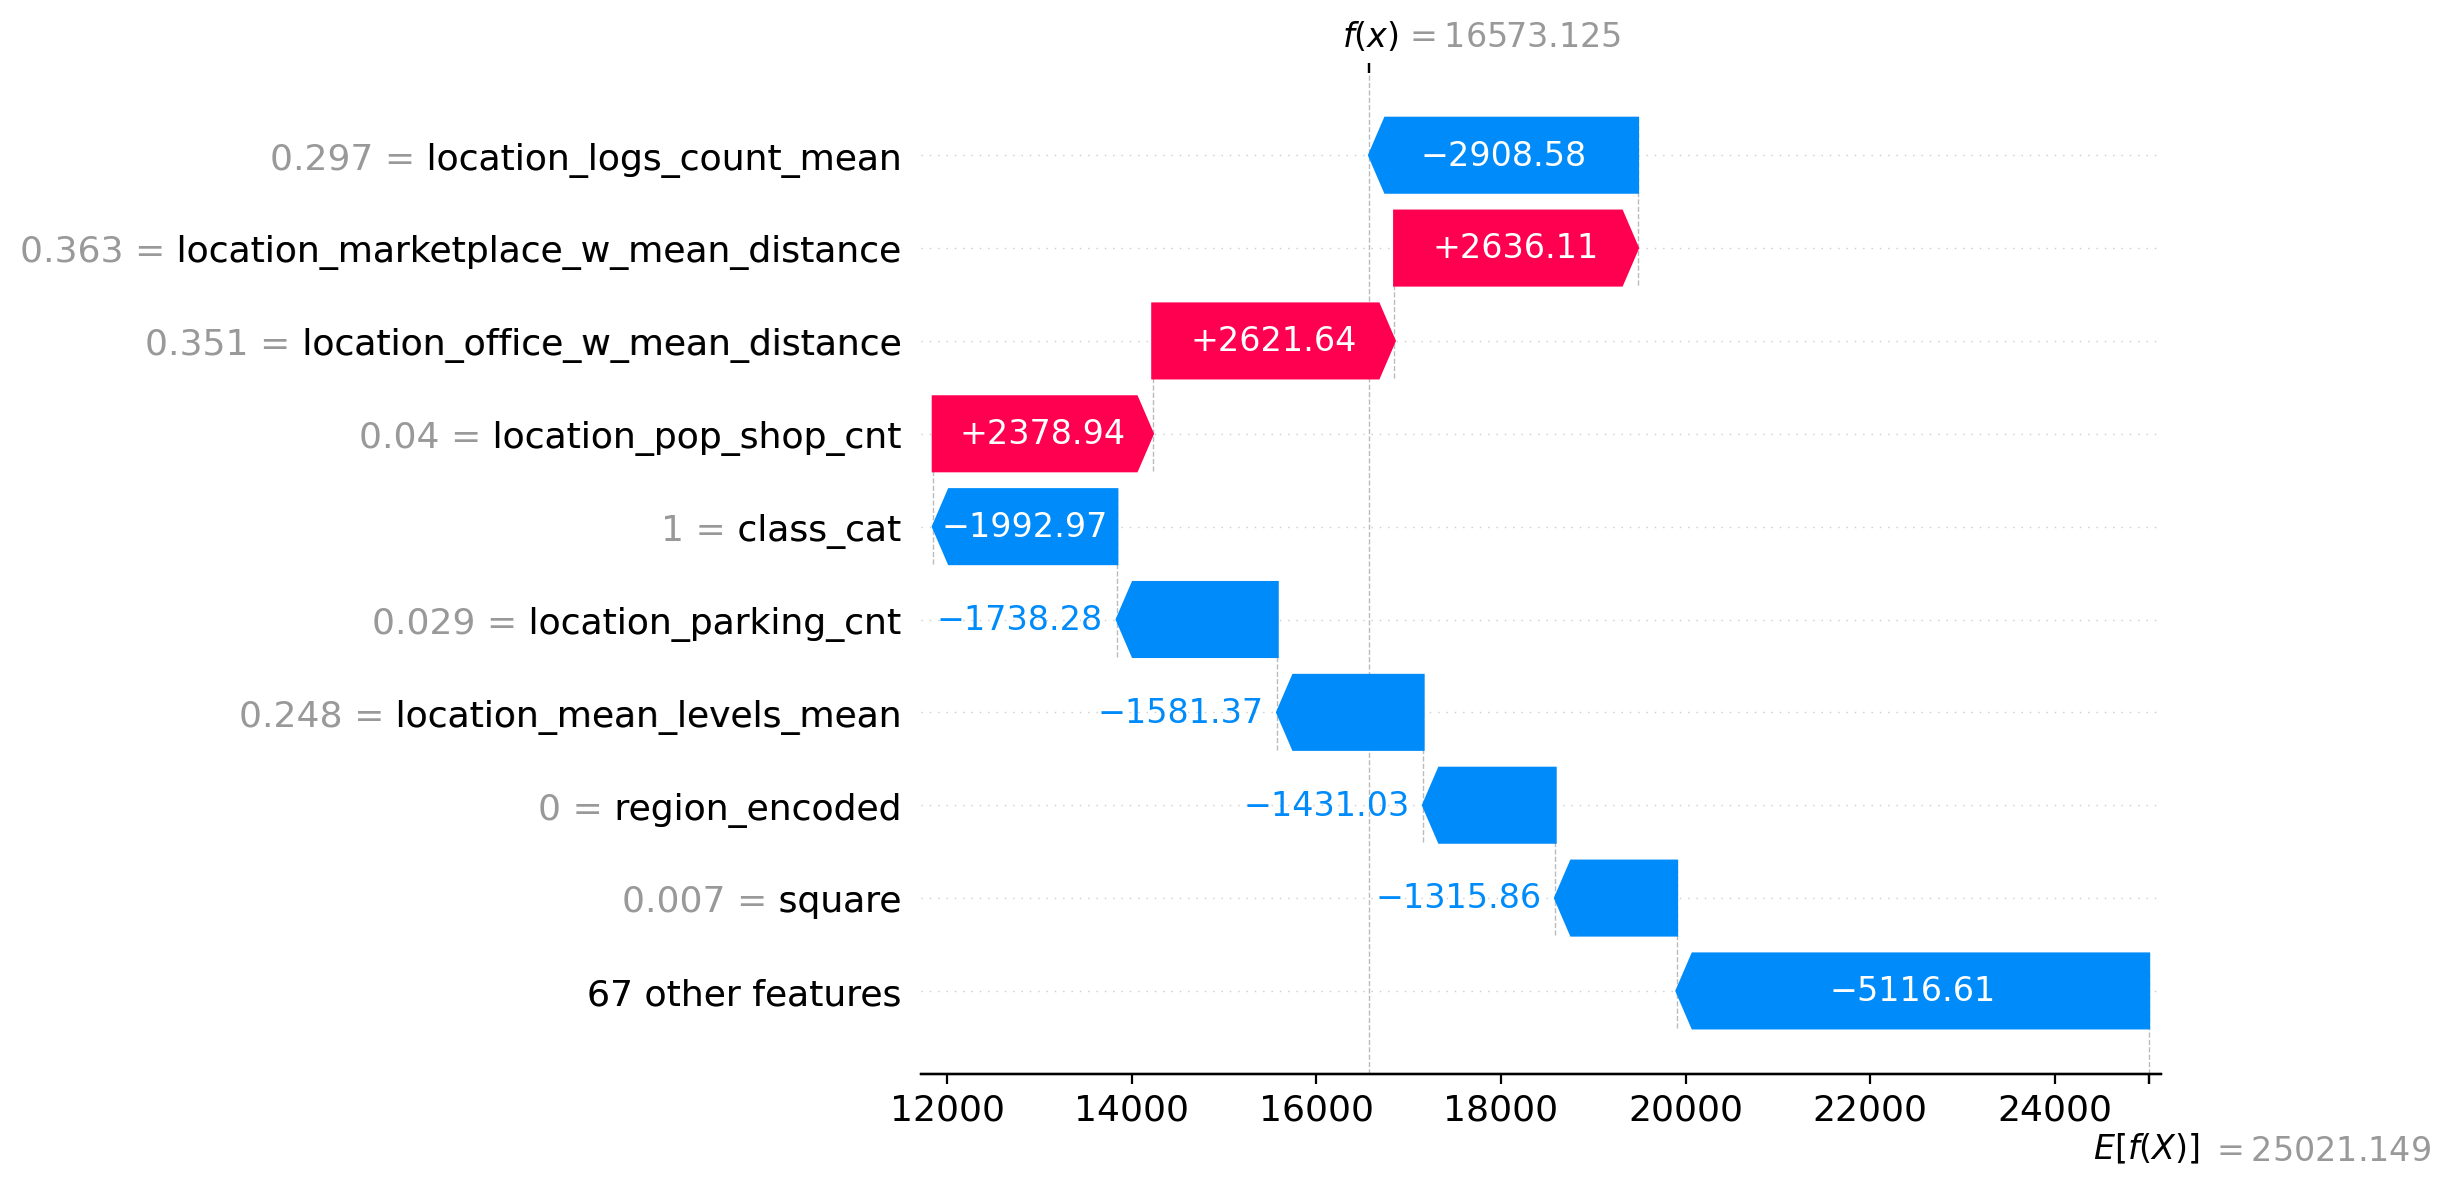

In [24]:

index = 0  
obj_idx = index % len(X_shap)
real    = float(y_shap[obj_idx])
pred    = float(boosting_model.predict(X_shap[obj_idx].reshape(1,-1))[0])
print(f"Реальная цена:       {real:.0f}")
print(f"Предсказание модели: {pred:.0f}")

print("\n--- GradientBoosting ---")
shap.waterfall_plot(shap.Explanation(
    values=shap_vals_b[obj_idx],
    base_values=base_b,
    data=X_shap[obj_idx],
    feature_names=numeric_columns
))

print("\n--- LinearRegression ---")
shap.waterfall_plot(shap.Explanation(
    values=shap_vals_l[obj_idx],
    base_values=base_l,
    data=X_shap[obj_idx],
    feature_names=numeric_columns
))

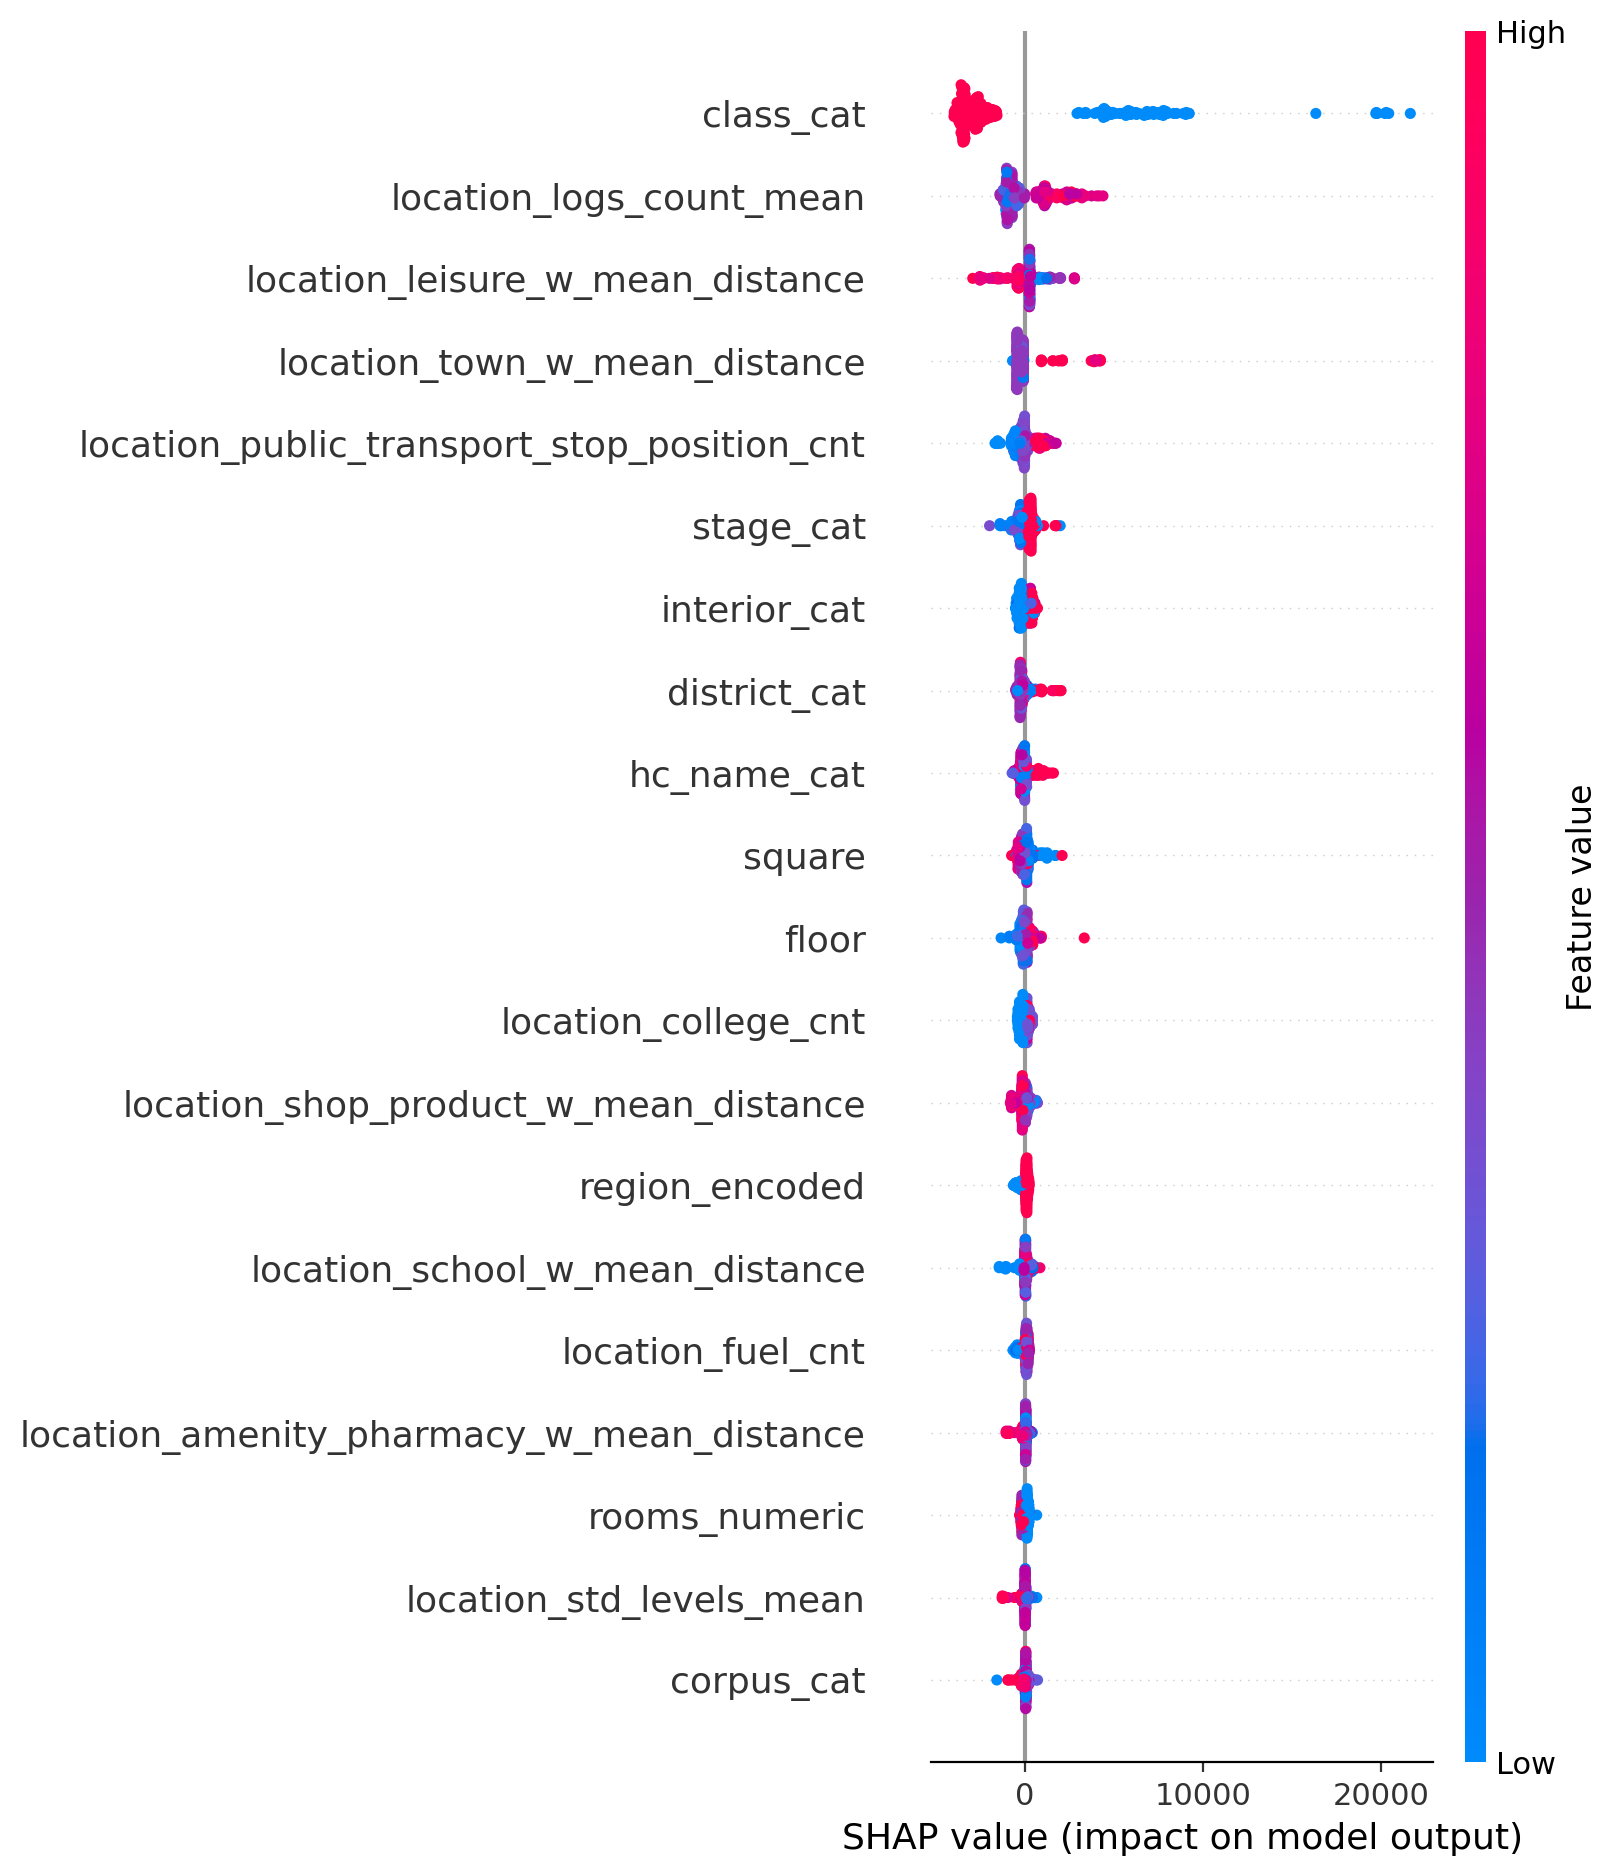

In [ ]:
# Summary plot
shap.summary_plot(shap_vals_b, X_shap,
                  feature_names=numeric_columns, max_display=20)